

Import Libraries & Konfigurasi

In [ ]:


import os, re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from collections import Counter
from google.colab import drive

warnings.filterwarnings("ignore")

# ── Visualization style ──────────────────────────────────────
sns.set_style("whitegrid")
sns.set_palette("Set2")
PLOT_TITLE_KWARGS = dict(fontsize=15, fontweight="bold", pad=12)
LABEL_KWARGS      = dict(fontsize=12)
COLOR_REAL = "#2196F3"   # biru → real
COLOR_FAKE = "#F44336"   # merah → fake

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


 Connect Google Drive

In [ ]:
drive.mount("/content/drive")

Mounted at /content/drive


 Load Dataset

In [ ]:
DATASET_PATH  = "/content/drive/MyDrive/machine learning/fake_job_postings.csv"
OUTPUT_FOLDER = "/content/drive/MyDrive/machine learning"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

df = pd.read_csv(DATASET_PATH)
df["fraudulent"] = df["fraudulent"].astype(int)
df["job_type"]   = df["fraudulent"].map({0: "Real", 1: "Fake"})

print("=" * 60)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("=" * 60)
print("\nFIRST 5 ROWS:")
display(df.head())

  DATASET LOADED SUCCESSFULLY
  Rows    : 17,880
  Columns : 19

FIRST 5 ROWS:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,job_type
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,Real
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,Real
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,Real
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Real
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Real


 Dataset Info & Dtypes

In [ ]:
print("=" * 60)
print("  DATASET INFO")
print("=" * 60)
df.info()

  DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  o

 Missing Values Report

In [ ]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count"      : missing,
    "Missing Percentage" : missing_pct
}).query("`Missing Count` > 0") \
  .sort_values("Missing Percentage", ascending=False)

print("=" * 60)
print("  MISSING VALUES REPORT")
print("=" * 60)
display(missing_report)

# Cek duplikat
dup_count = df.duplicated().sum()
print(f"\n  DUPLICATE ROWS : {dup_count:,}")

  MISSING VALUES REPORT


,Missing Count,Missing Percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08



  DUPLICATE ROWS : 0


 Missing Values Chart

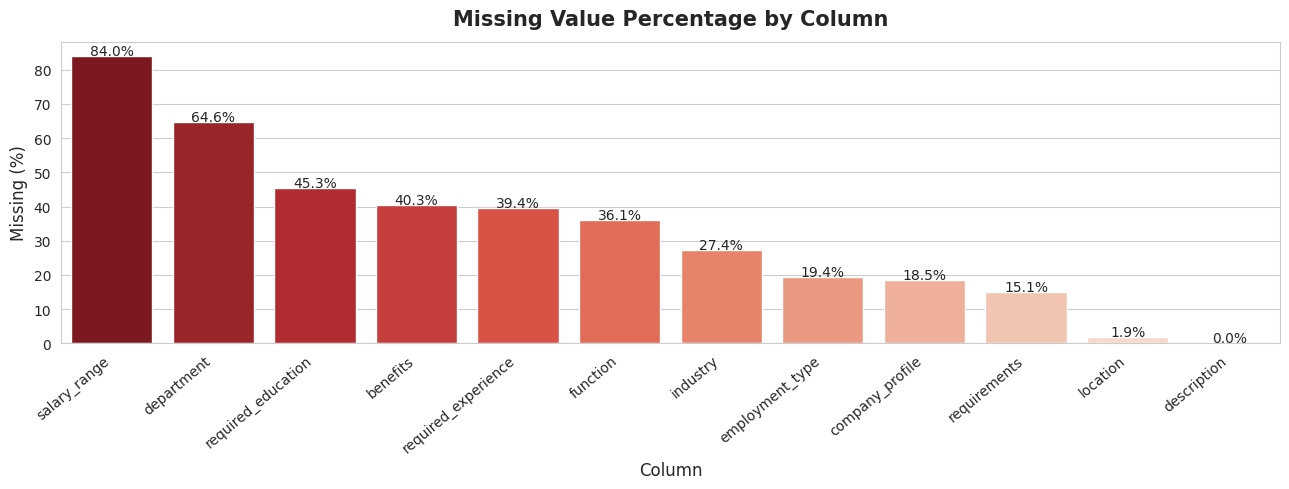

In [ ]:
if not missing_report.empty:
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.barplot(
        x=missing_report.index,
        y=missing_report["Missing Percentage"],
        palette="Reds_r", ax=ax
    )
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
            ha="center", fontsize=10
        )
    ax.set_title("Missing Value Percentage by Column", **PLOT_TITLE_KWARGS)
    ax.set_xlabel("Column", **LABEL_KWARGS)
    ax.set_ylabel("Missing (%)", **LABEL_KWARGS)
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, "missing_values.png"), dpi=150)
    plt.show()

 Remove Duplicates

In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print("=" * 60)
print(f"  Removed : {before - after:,} duplicate row(s)")
print(f"  Shape   : {df.shape}")
print("=" * 60)

  Removed : 0 duplicate row(s)
  Shape   : (17880, 19)


 Buat Binary Missing Indicators


In [ ]:
# ── Binary indicator: apakah kolom ini diisi atau tidak ──────
# Dibuat SEBELUM fillna() supaya kita tahu mana yang aslinya kosong.
df["has_company_profile"] = df["company_profile"].notna().astype(int)
df["has_requirements"]    = df["requirements"].notna().astype(int)
df["has_benefits"]        = df["benefits"].notna().astype(int)
df["has_salary_range"]    = df["salary_range"].notna().astype(int)

# ── Metadata biner dari dataset (langsung ada di kolom) ──────
df["has_company_logo"] = df["has_company_logo"].fillna(0).astype(int)
df["telecommuting"]    = df["telecommuting"].fillna(0).astype(int)
df["has_questions"]    = df["has_questions"].fillna(0).astype(int)

BINARY_FEATURES = [
    "has_company_profile", "has_requirements", "has_benefits",
    "has_salary_range", "has_company_logo", "telecommuting", "has_questions"
]

print("=" * 60)
print("  BINARY FEATURES CREATED")
print("=" * 60)
display(
    df.groupby("fraudulent")[BINARY_FEATURES]
      .mean()
      .rename(index={0: "Real", 1: "Fake"})
      .round(3)
      .style.background_gradient(cmap="RdYlGn", axis=0)
)
print("\n  Nilai mendekati 1.0 = hampir selalu diisi")
print("  Nilai mendekati 0.0 = sering kosong")

  BINARY FEATURES CREATED


,has_company_profile,has_requirements,has_benefits,has_salary_range,has_company_logo,telecommuting,has_questions
fraudulent,,,,,,,
Real,0.840000,0.851000,0.598000,0.155000,0.819000,0.041000,0.502000
Fake,0.322000,0.822000,0.580000,0.258000,0.327000,0.074000,0.289000



  Nilai mendekati 1.0 = hampir selalu diisi
  Nilai mendekati 0.0 = sering kosong


 EDA: Binary Features vs Fraudulent (BARU)

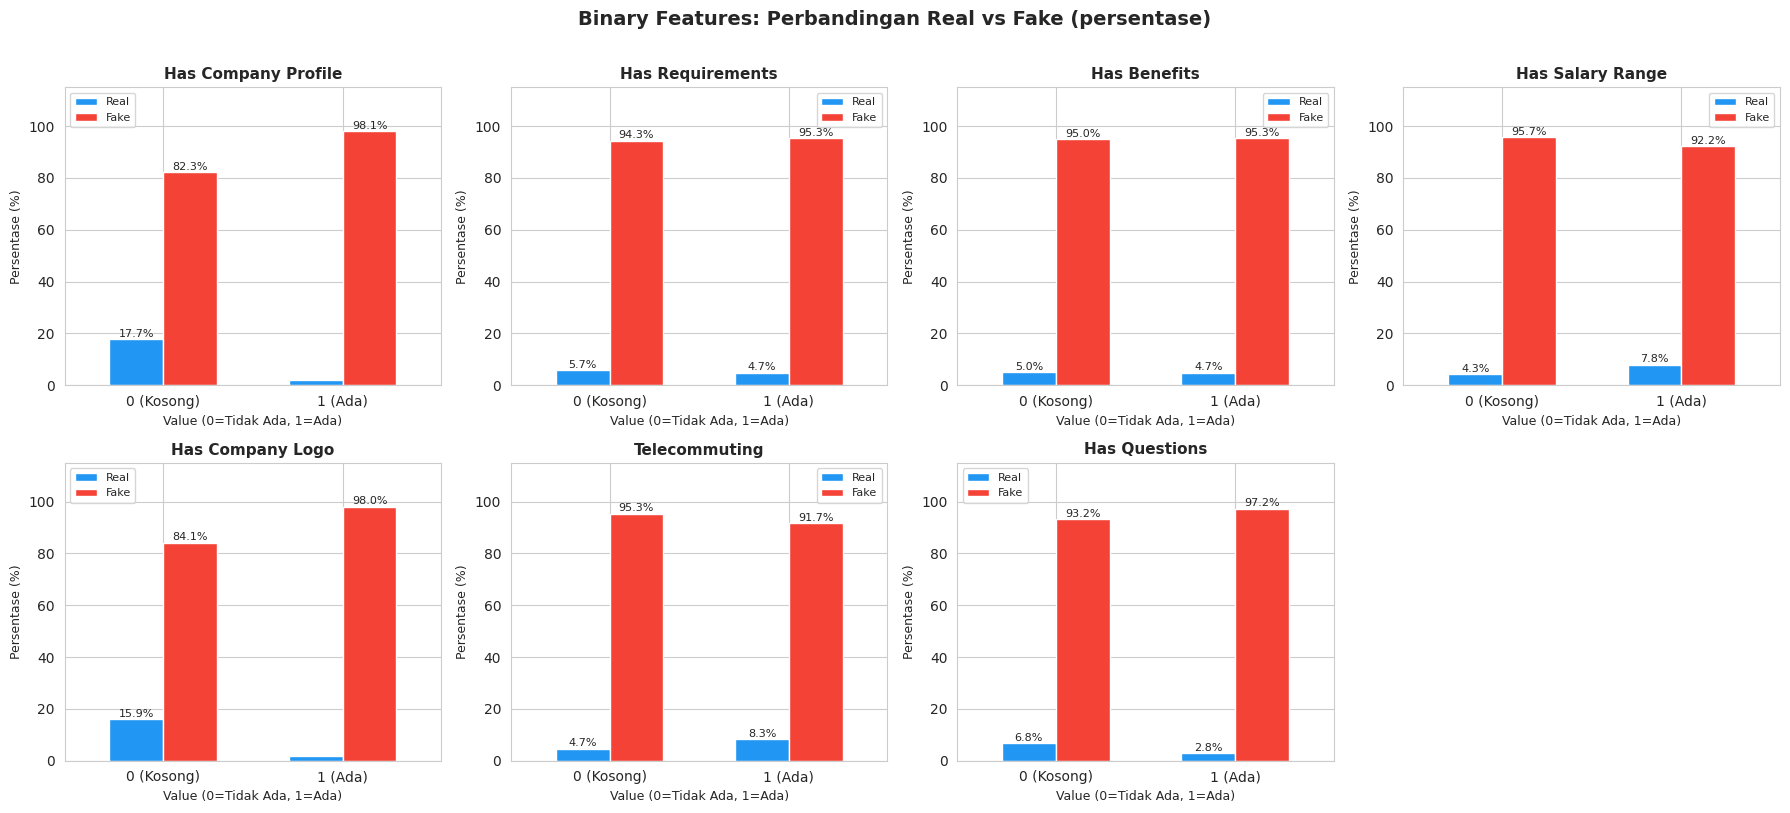

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes_flat = axes.flatten()

for i, feat in enumerate(BINARY_FEATURES):
    ct = df.groupby([feat, "job_type"]).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct_pct.plot(
        kind="bar", ax=axes_flat[i],
        color=[COLOR_REAL, COLOR_FAKE],
        edgecolor="white", width=0.6
    )
    axes_flat[i].set_title(feat.replace("_", " ").title(),
                           fontsize=11, fontweight="bold")
    axes_flat[i].set_xlabel("Value (0=Tidak Ada, 1=Ada)", fontsize=9)
    axes_flat[i].set_ylabel("Persentase (%)", fontsize=9)
    axes_flat[i].set_xticklabels(["0 (Kosong)", "1 (Ada)"], rotation=0)
    axes_flat[i].legend(["Real", "Fake"], fontsize=8)
    axes_flat[i].set_ylim(0, 115)

    for bar in axes_flat[i].patches:
        h = bar.get_height()
        if h > 2:
            axes_flat[i].text(
                bar.get_x() + bar.get_width() / 2, h + 1,
                f"{h:.1f}%", ha="center", fontsize=8
            )

# Sembunyikan subplot terakhir (7 fitur, 8 slot)
axes_flat[-1].set_visible(False)

plt.suptitle(
    "Binary Features: Perbandingan Real vs Fake (persentase)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "binary_features_eda.png"),
            dpi=150, bbox_inches="tight")
plt.show()

 Handle Missing Values

In [ ]:
TEXT_COLUMNS = ["title", "company_profile", "description", "requirements", "benefits"]

for col in TEXT_COLUMNS:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

# Kategorikal — isi dengan "Unknown"
CAT_COLUMNS = ["employment_type", "required_experience",
               "required_education", "industry", "function"]
for col in CAT_COLUMNS:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

print("=" * 60)
print("  MISSING VALUES AFTER CLEANING")
print("=" * 60)
display(df[TEXT_COLUMNS].isnull().sum().rename("Remaining NaN"))

  MISSING VALUES AFTER CLEANING


,Remaining NaN
title,0
company_profile,0
description,0
requirements,0
benefits,0


 Target Distribution (Statistik)

In [ ]:
real_count = (df["fraudulent"] == 0).sum()
fake_count = (df["fraudulent"] == 1).sum()
total      = len(df)

print("=" * 60)
print("  TARGET DISTRIBUTION")
print("=" * 60)
print(f"  Real Jobs : {real_count:,}  ({real_count/total*100:.1f}%)")
print(f"  Fake Jobs : {fake_count:,}  ({fake_count/total*100:.1f}%)")
print(f"  Ratio     : {real_count/fake_count:.1f} : 1  (Real : Fake)")
print("=" * 60)
print("\n  ⚠ Dataset sangat imbalanced — SMOTE diperlukan saat training!")

  TARGET DISTRIBUTION
  Real Jobs : 17,014  (95.2%)
  Fake Jobs : 866  (4.8%)
  Ratio     : 19.6 : 1  (Real : Fake)

  ⚠ Dataset sangat imbalanced — SMOTE diperlukan saat training!


Target Distribution Chart

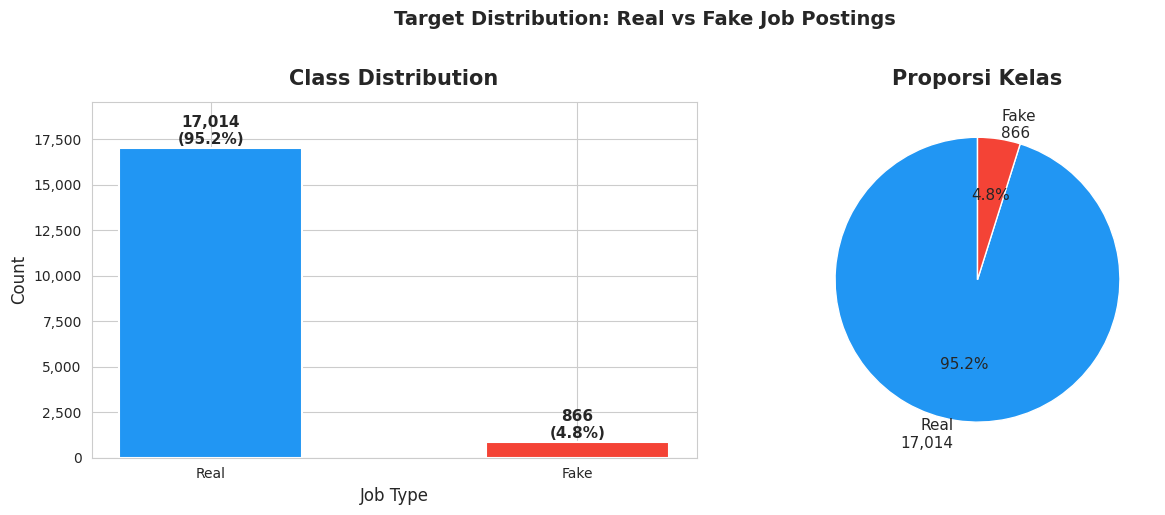

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(
    ["Real", "Fake"], [real_count, fake_count],
    color=[COLOR_REAL, COLOR_FAKE],
    edgecolor="white", linewidth=1.5, width=0.5
)
for bar, count in zip(bars, [real_count, fake_count]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}\n({count/total*100:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
axes[0].set_title("Class Distribution", **PLOT_TITLE_KWARGS)
axes[0].set_xlabel("Job Type", **LABEL_KWARGS)
axes[0].set_ylabel("Count", **LABEL_KWARGS)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].set_ylim(0, real_count * 1.15)

# Pie chart
axes[1].pie(
    [real_count, fake_count],
    labels=[f"Real\n{real_count:,}", f"Fake\n{fake_count:,}"],
    colors=[COLOR_REAL, COLOR_FAKE],
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 11}
)
axes[1].set_title("Proporsi Kelas", **PLOT_TITLE_KWARGS)

plt.suptitle("Target Distribution: Real vs Fake Job Postings",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "target_distribution.png"), dpi=150)
plt.show()

 EDA: Employment Type vs Fraudulent

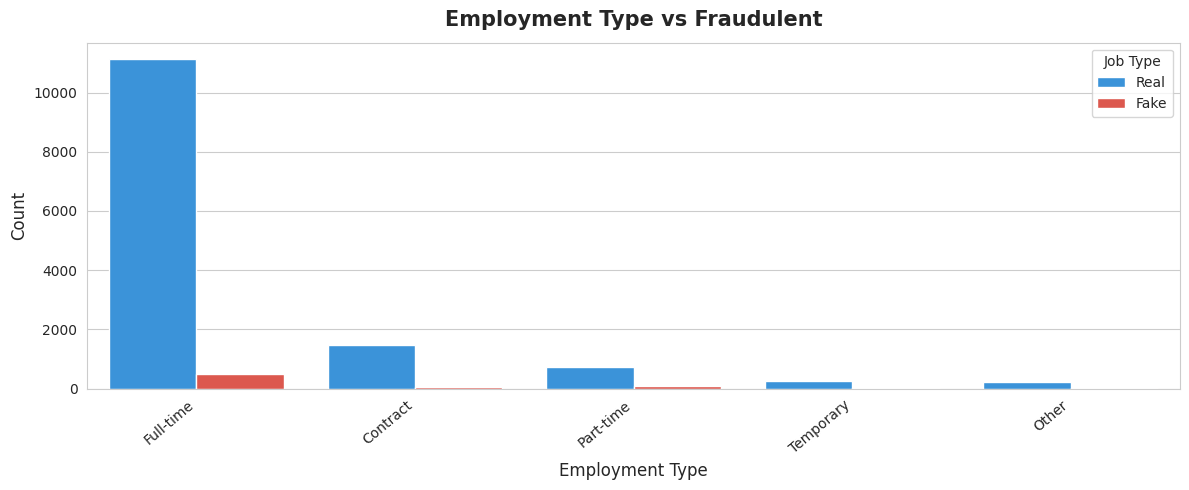

In [ ]:
if "employment_type" in df.columns:
    order = (df["employment_type"]
               .replace("Unknown", float("nan"))
               .dropna()
               .value_counts()
               .index.tolist())

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.countplot(
        data=df[df["employment_type"] != "Unknown"],
        x="employment_type", hue="job_type",
        hue_order=["Real", "Fake"], order=order,
        palette={"Real": COLOR_REAL, "Fake": COLOR_FAKE}, ax=ax
    )
    ax.set_title("Employment Type vs Fraudulent", **PLOT_TITLE_KWARGS)
    ax.set_xlabel("Employment Type", **LABEL_KWARGS)
    ax.set_ylabel("Count", **LABEL_KWARGS)
    ax.legend(title="Job Type")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()

 EDA: Required Experience vs Fraudulent

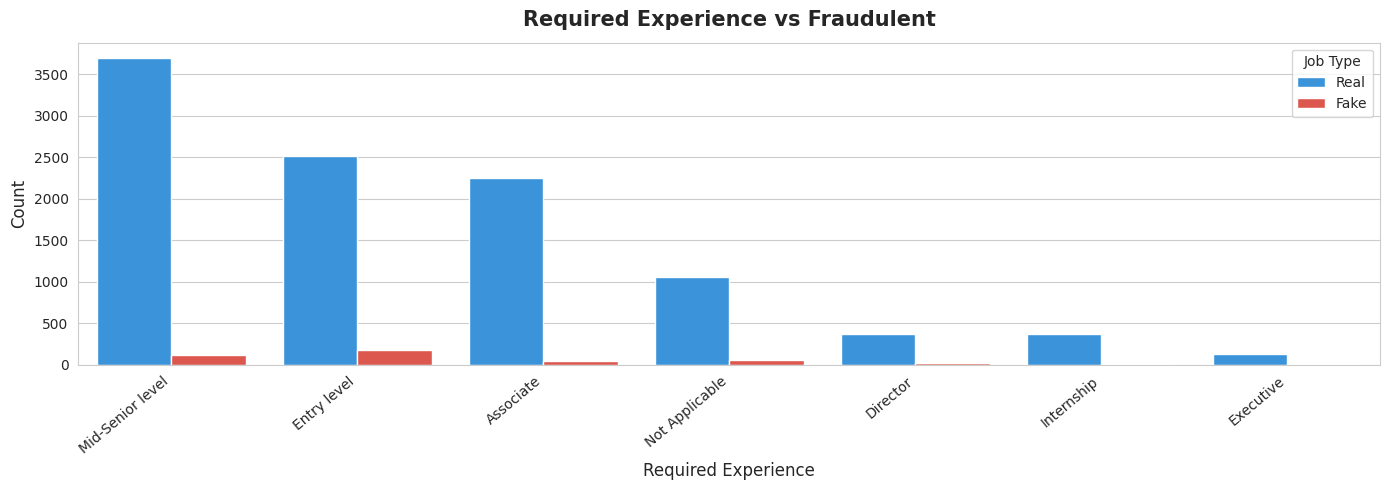

In [ ]:
if "required_experience" in df.columns:
    exp_order = (df["required_experience"]
                   .replace("Unknown", float("nan"))
                   .dropna()
                   .value_counts()
                   .index.tolist())

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.countplot(
        data=df[df["required_experience"] != "Unknown"],
        x="required_experience", hue="job_type",
        hue_order=["Real", "Fake"], order=exp_order,
        palette={"Real": COLOR_REAL, "Fake": COLOR_FAKE}, ax=ax
    )
    ax.set_title("Required Experience vs Fraudulent", **PLOT_TITLE_KWARGS)
    ax.set_xlabel("Required Experience", **LABEL_KWARGS)
    ax.set_ylabel("Count", **LABEL_KWARGS)
    ax.legend(title="Job Type")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()

EDA: Required Education vs Fraudulent (BARU)

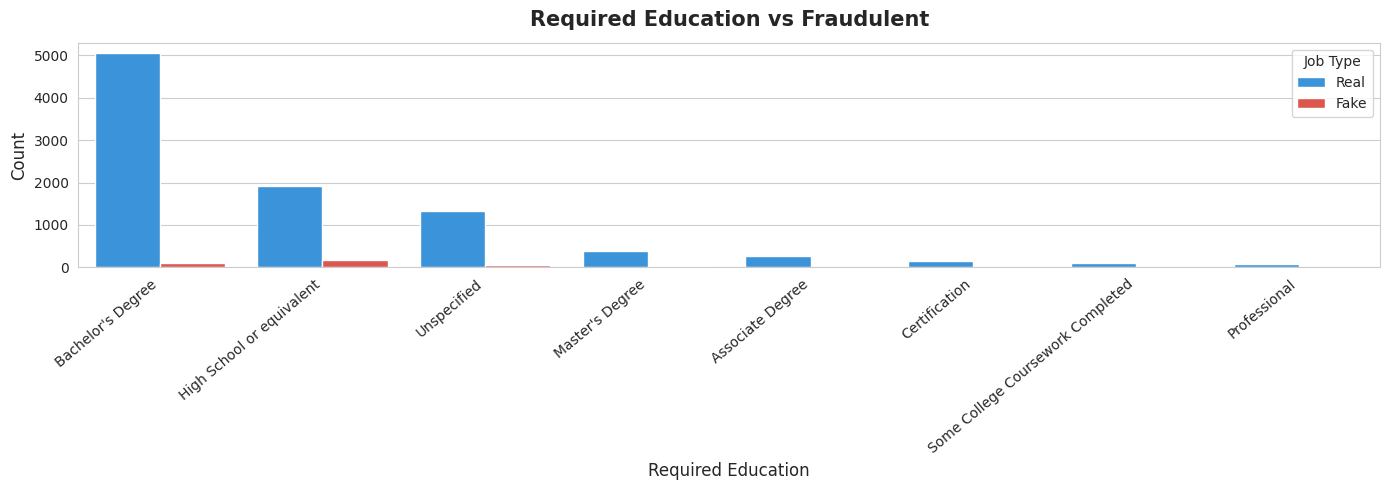

In [ ]:
if "required_education" in df.columns:
    edu_order = (df["required_education"]
                   .replace("Unknown", float("nan"))
                   .dropna()
                   .value_counts()
                   .head(8)
                   .index.tolist())

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.countplot(
        data=df[df["required_education"].isin(edu_order)],
        x="required_education", hue="job_type",
        hue_order=["Real", "Fake"], order=edu_order,
        palette={"Real": COLOR_REAL, "Fake": COLOR_FAKE}, ax=ax
    )
    ax.set_title("Required Education vs Fraudulent", **PLOT_TITLE_KWARGS)
    ax.set_xlabel("Required Education", **LABEL_KWARGS)
    ax.set_ylabel("Count", **LABEL_KWARGS)
    ax.legend(title="Job Type")
    plt.xticks(rotation=40, ha="right")
    plt.tight_layout()
    plt.show()

 Combine Text Columns


In [ ]:
# Cara baru: lebih aman dari munculnya string 'nan'
TEXT_COLS = ["title", "company_profile", "description", "requirements", "benefits"]
df["full_text"] = df[TEXT_COLS].apply(
    lambda row: " ".join(row.fillna("").astype(str)), axis=1
)

# Raw word count sebelum cleaning (fitur tambahan)
df["raw_word_count"] = df["full_text"].apply(lambda t: len(t.split()))

print("=" * 60)
print("  COMBINED TEXT COLUMN — SAMPLE")
print("=" * 60)
display(df[["title", "full_text", "raw_word_count"]].head(3))

print(f"\n  Rata-rata raw word count — Real : {df[df['fraudulent']==0]['raw_word_count'].mean():.0f} kata")
print(f"  Rata-rata raw word count — Fake : {df[df['fraudulent']==1]['raw_word_count'].mean():.0f} kata")

  COMBINED TEXT COLUMN — SAMPLE


,title,full_text,raw_word_count
0,Marketing Intern,"Marketing Intern We're Food52, and we've creat...",382
1,Customer Service - Cloud Video Production,Customer Service - Cloud Video Production 90 S...,901
2,Commissioning Machinery Assistant (CMA),Commissioning Machinery Assistant (CMA) Valor ...,359



  Rata-rata raw word count — Real : 379 kata
  Rata-rata raw word count — Fake : 282 kata


 Text Cleaning Function


In [ ]:
def clean_text(text: str) -> str:
    """
    Lowercase → strip unicode/emoji → remove URLs → remove HTML →
    remove digits → remove punctuation → strip extra whitespace.
    """
    text = str(text).lower()
    # Hapus karakter non-ASCII (emoji, simbol unicode, dll)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"http\S+|www\.\S+", "", text)    # URLs
    text = re.sub(r"<[^>]+>",            "", text)    # HTML tags
    text = re.sub(r"\d+",               "", text)    # angka
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+",              " ", text).strip()
    return text

# Test fungsi
sample = "Apply NOW!! 💰 Earn $500/week from HOME! Visit https://scam.com <b>URGENT</b>"
print(f"  Input  : {sample}")
print(f"  Output : {clean_text(sample)}")

  Input  : Apply NOW!! 💰 Earn $500/week from HOME! Visit https://scam.com <b>URGENT</b>
  Output : apply now earn week from home visit urgent


 Apply Text Cleaning

In [ ]:
df["clean_text"] = df["full_text"].apply(clean_text)

print("=" * 60)
print("  CLEANED TEXT — SAMPLE")
print("=" * 60)
display(df[["title", "full_text", "clean_text"]].head(3))

  CLEANED TEXT — SAMPLE


,title,full_text,clean_text
0,Marketing Intern,"Marketing Intern We're Food52, and we've creat...",marketing intern were food and weve created a ...
1,Customer Service - Cloud Video Production,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA),Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...


 Custom Stopwords Definition

In [ ]:
# Kata-kata domain yang terlalu umum untuk membedakan Real vs Fake
CUSTOM_STOPWORDS = {
    "experience", "work", "working", "team",
    "job", "jobs", "skills", "skill", "candidate",
    "company", "looking", "ability", "new",
    "year", "years", "business", "employee",
    "employees", "position", "role", "opportunity",
    "great", "good", "time", "need", "provide",
    "including", "required", "will", "must"
}

ALL_STOPWORDS = ENGLISH_STOP_WORDS.union(CUSTOM_STOPWORDS)

print(f"  Total stopwords : {len(ALL_STOPWORDS):,}")
print(f"  Sklearn default : {len(ENGLISH_STOP_WORDS)}")
print(f"  Custom added    : {len(CUSTOM_STOPWORDS)}")

  Total stopwords : 346
  Sklearn default : 318
  Custom added    : 30


 Apply Stopword Removal

In [ ]:
def remove_stopwords(text: str) -> str:
    """Hapus English + custom domain stopwords."""
    return " ".join(
        w for w in text.split() if w not in ALL_STOPWORDS
    )

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

print("=" * 60)
print("  TEXT AFTER STOPWORD REMOVAL — SAMPLE")
print("=" * 60)
display(df[["clean_text"]].head(3))

  TEXT AFTER STOPWORD REMOVAL — SAMPLE


,clean_text
0,marketing intern food weve created groundbreak...
1,customer service cloud video production second...
2,commissioning machinery assistant cma valor se...


 Text Length Distribution

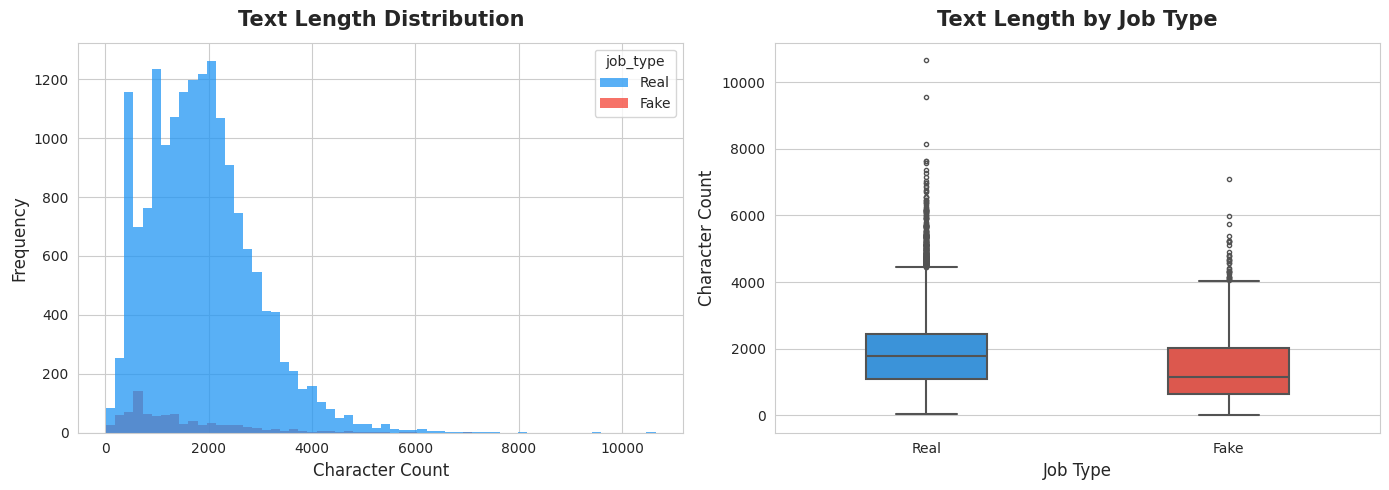

In [ ]:
df["text_length"] = df["clean_text"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df, x="text_length", hue="job_type",
    hue_order=["Real", "Fake"], bins=60,
    palette={"Real": COLOR_REAL, "Fake": COLOR_FAKE},
    ax=axes[0], alpha=0.75, edgecolor="none"
)
axes[0].set_title("Text Length Distribution", **PLOT_TITLE_KWARGS)
axes[0].set_xlabel("Character Count", **LABEL_KWARGS)
axes[0].set_ylabel("Frequency", **LABEL_KWARGS)

sns.boxplot(
    data=df, x="job_type", y="text_length",
    order=["Real", "Fake"],
    palette={"Real": COLOR_REAL, "Fake": COLOR_FAKE},
    width=0.4, linewidth=1.5, fliersize=3, ax=axes[1]
)
axes[1].set_title("Text Length by Job Type", **PLOT_TITLE_KWARGS)
axes[1].set_xlabel("Job Type", **LABEL_KWARGS)
axes[1].set_ylabel("Character Count", **LABEL_KWARGS)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "text_length.png"), dpi=150)
plt.show()

 Text Length Statistics

In [ ]:
print("=" * 60)
print("  TEXT LENGTH STATISTICS")
print("=" * 60)
display(
    df.groupby("fraudulent")["text_length"]
      .describe()
      .rename(index={0: "Real", 1: "Fake"})
      .round(1)
)
print("\n  Raw word count sebelum stopword removal:")
display(
    df.groupby("fraudulent")["raw_word_count"]
      .describe()
      .rename(index={0: "Real", 1: "Fake"})
      .round(1)
)

  TEXT LENGTH STATISTICS


,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
Real,17014.0,1860.5,1017.3,51.0,1088.0,1775.5,2436.8,10651.0
Fake,866.0,1444.3,1114.0,14.0,656.5,1149.5,2025.0,7105.0



  Raw word count sebelum stopword removal:


,count,mean,std,min,25%,50%,75%,max
fraudulent,,,,,,,,
Real,17014.0,379.5,206.7,7.0,235.0,355.0,496.0,2118.0
Fake,866.0,282.3,203.9,2.0,133.0,224.5,384.2,1338.0


 WordCloud: Real Job Postings

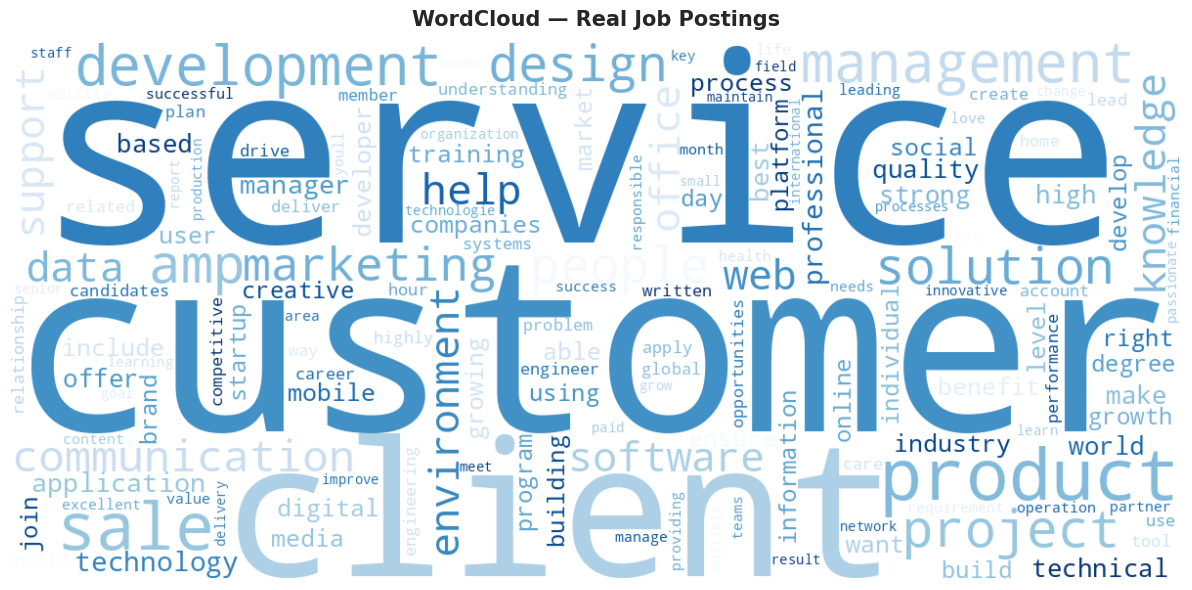

In [ ]:
real_text = " ".join(df[df["fraudulent"] == 0]["clean_text"])

wc_real = WordCloud(
    width=1200, height=550,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False
).generate(real_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc_real, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Real Job Postings", **PLOT_TITLE_KWARGS)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "wordcloud_real.png"), dpi=150)
plt.show()

 WordCloud: Fake Job Postings

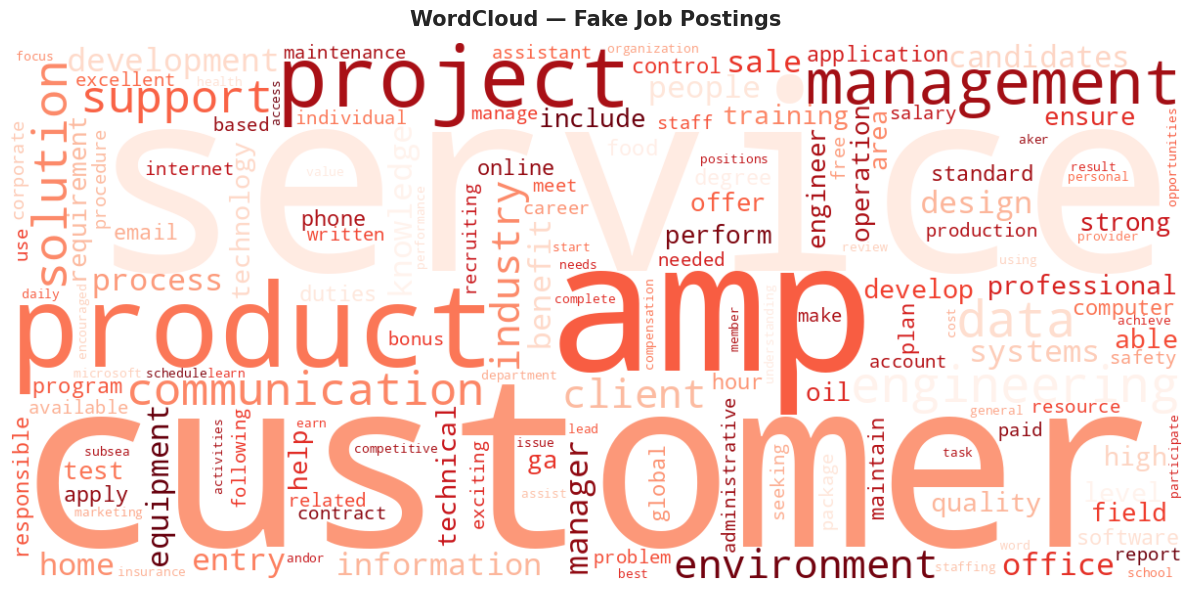

In [ ]:
fake_text = " ".join(df[df["fraudulent"] == 1]["clean_text"])

wc_fake = WordCloud(
    width=1200, height=550,
    background_color="white",
    colormap="Reds",
    max_words=150,
    collocations=False
).generate(fake_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc_fake, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Fake Job Postings", **PLOT_TITLE_KWARGS)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "wordcloud_fake.png"), dpi=150)
plt.show()

Top 20 Words: Real vs Fake

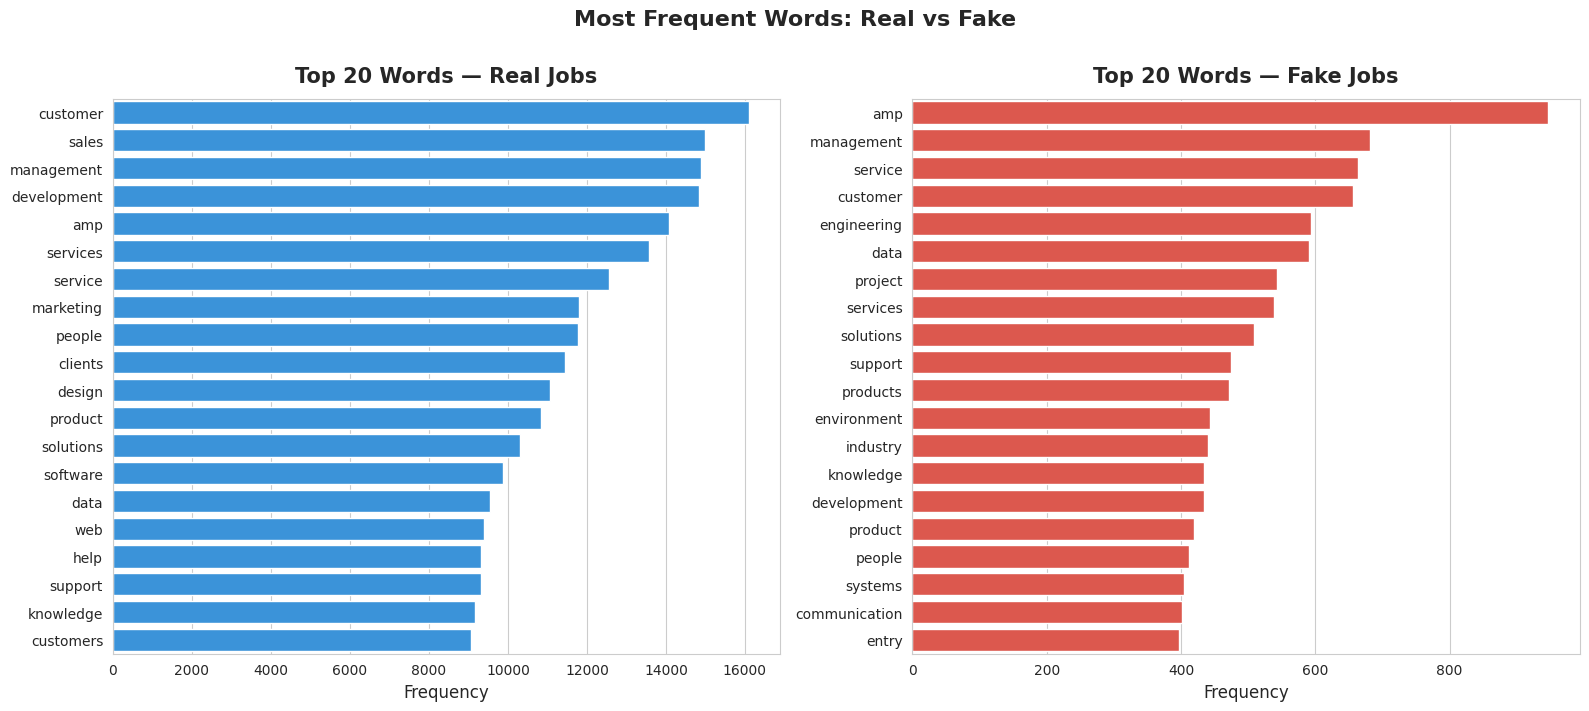

In [ ]:
def top_n_words(text_series: pd.Series, n: int = 20) -> pd.DataFrame:
    words = " ".join(text_series).split()
    freq  = Counter(words).most_common(n)
    return pd.DataFrame(freq, columns=["Word", "Frequency"])

top_real = top_n_words(df[df["fraudulent"] == 0]["clean_text"])
top_fake = top_n_words(df[df["fraudulent"] == 1]["clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_real, x="Frequency", y="Word", color=COLOR_REAL, ax=axes[0])
axes[0].set_title("Top 20 Words — Real Jobs", **PLOT_TITLE_KWARGS)
axes[0].set_xlabel("Frequency", **LABEL_KWARGS)
axes[0].set_ylabel("")

sns.barplot(data=top_fake, x="Frequency", y="Word", color=COLOR_FAKE, ax=axes[1])
axes[1].set_title("Top 20 Words — Fake Jobs", **PLOT_TITLE_KWARGS)
axes[1].set_xlabel("Frequency", **LABEL_KWARGS)
axes[1].set_ylabel("")

plt.suptitle("Most Frequent Words: Real vs Fake",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "top_words.png"), dpi=150)
plt.show()

 Feature Engineering: Fitur Numerik

In [ ]:
# ── Fitur numerik dari teks ────────────────────────────────────
df["uppercase_count"]   = df["full_text"].apply(lambda t: sum(c.isupper() for c in t))
df["exclamation_count"] = df["full_text"].apply(lambda t: t.count("!"))
df["question_count"]    = df["full_text"].apply(lambda t: t.count("?"))
df["word_count"]        = df["clean_text"].apply(lambda t: len(t.split()))
df["avg_word_length"]   = df["clean_text"].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)

NUMERIC_FEATURES = [
    "uppercase_count", "exclamation_count",
    "question_count", "word_count", "avg_word_length",
    "raw_word_count"
]

# Gabung semua engineered features (numerik + biner)
ENGINEERED_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES

print("=" * 60)
print(f"  Total engineered features : {len(ENGINEERED_FEATURES)}")
print(f"  Numeric : {len(NUMERIC_FEATURES)}")
print(f"  Binary  : {len(BINARY_FEATURES)}")
print("=" * 60)
display(df[ENGINEERED_FEATURES].head())

  Total engineered features : 13
  Numeric : 6
  Binary  : 7


,uppercase_count,exclamation_count,question_count,word_count,avg_word_length,raw_word_count,has_company_profile,has_requirements,has_benefits,has_salary_range,has_company_logo,telecommuting,has_questions
0,87,1,0,217,7.709677,382,1,1,0,0,1,0,0
1,171,5,4,442,7.282805,901,1,1,1,0,1,0,0
2,64,0,0,197,8.796954,359,1,1,0,0,1,0,0
3,154,0,0,424,8.688679,709,1,1,1,0,1,0,0
4,289,0,1,321,8.772586,470,1,1,1,0,1,0,1


 Perbandingan Mean Fitur: Real vs Fake

In [ ]:
print("=" * 60)
print("  MEAN ENGINEERED FEATURES BY JOB TYPE")
print("=" * 60)
display(
    df.groupby("fraudulent")[ENGINEERED_FEATURES]
      .mean()
      .rename(index={0: "Real", 1: "Fake"})
      .round(3)
      .style.background_gradient(cmap="RdYlGn_r", axis=0)
)

  MEAN ENGINEERED FEATURES BY JOB TYPE


,uppercase_count,exclamation_count,question_count,word_count,avg_word_length,raw_word_count,has_company_profile,has_requirements,has_benefits,has_salary_range,has_company_logo,telecommuting,has_questions
fraudulent,,,,,,,,,,,,,
Real,91.248000,0.668000,0.462000,206.330000,8.060000,379.491000,0.840000,0.851000,0.598000,0.155000,0.819000,0.041000,0.502000
Fake,89.753000,0.554000,0.204000,157.688000,8.023000,282.333000,0.322000,0.822000,0.580000,0.258000,0.327000,0.074000,0.289000


Boxplot Fitur Numerik: Real vs Fake

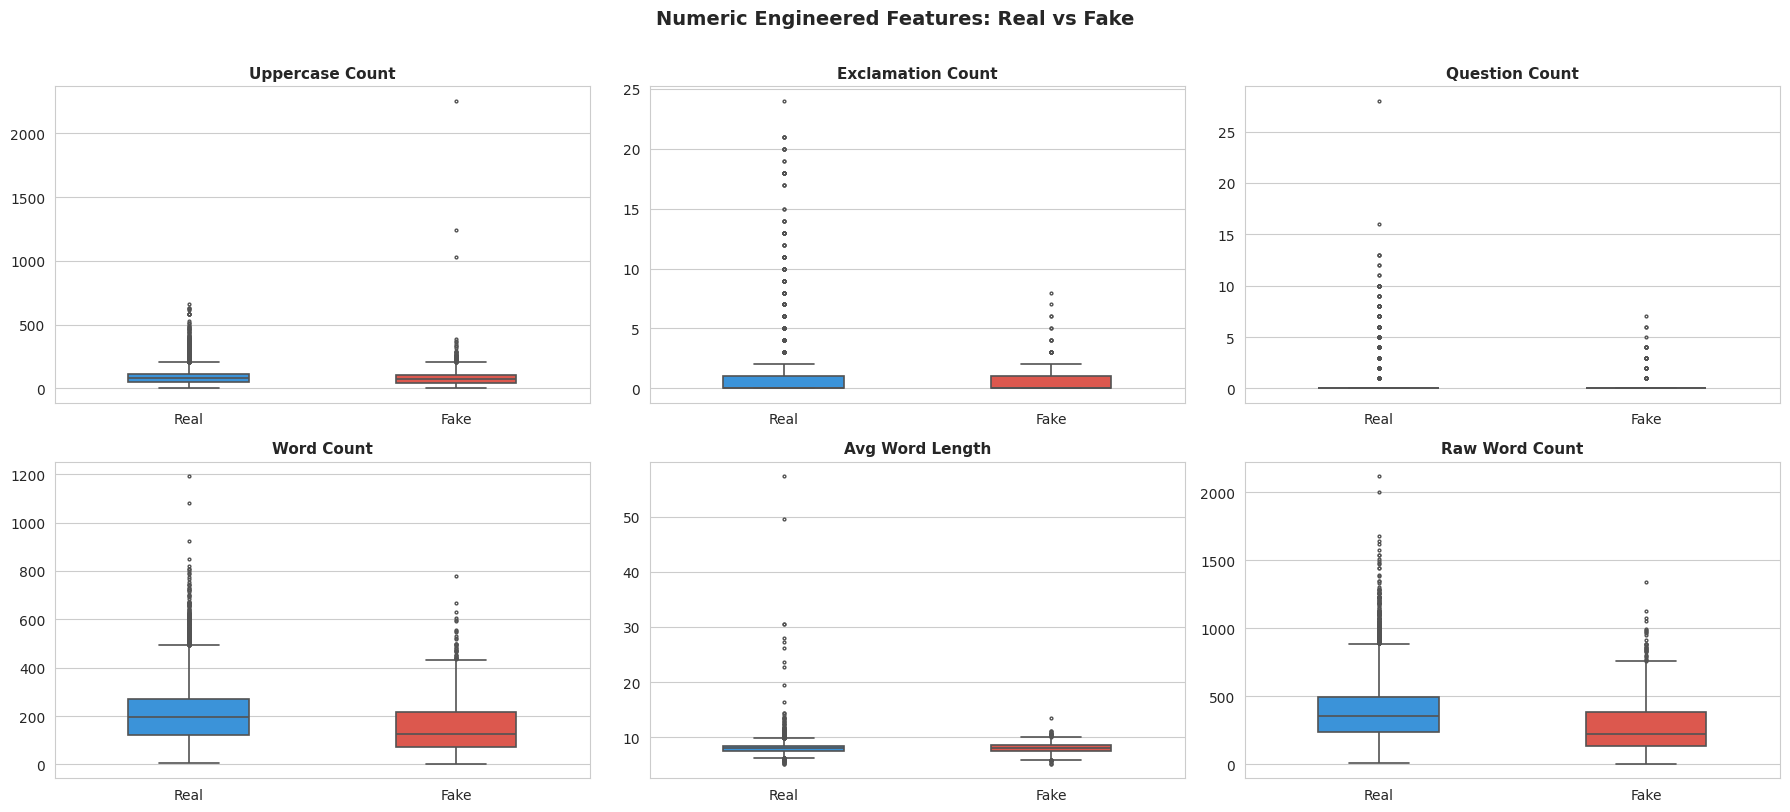

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes_flat = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    sns.boxplot(
        data=df, x="job_type", y=feat,
        order=["Real", "Fake"],
        palette={"Real": COLOR_REAL, "Fake": COLOR_FAKE},
        width=0.45, linewidth=1.2, fliersize=2,
        ax=axes_flat[i]
    )
    axes_flat[i].set_title(feat.replace("_", " ").title(),
                           fontsize=11, fontweight="bold")
    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel("")

plt.suptitle("Numeric Engineered Features: Real vs Fake",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "feature_boxplot.png"), dpi=150)
plt.show()

TF-IDF Feature Extraction

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = tfidf.fit_transform(df["clean_text"])
y = df["fraudulent"]

print("=" * 60)
print("  TF-IDF RESULT")
print("=" * 60)
print(f"  Feature Matrix Shape : {X.shape}")
print(f"  Target Shape         : {y.shape}")
print(f"  Vocabulary Size      : {len(tfidf.vocabulary_):,}")
print("=" * 60)

  TF-IDF RESULT
  Feature Matrix Shape : (17880, 5000)
  Target Shape         : (17880,)
  Vocabulary Size      : 5,000


Top 20 Terms by Mean TF-IDF Score

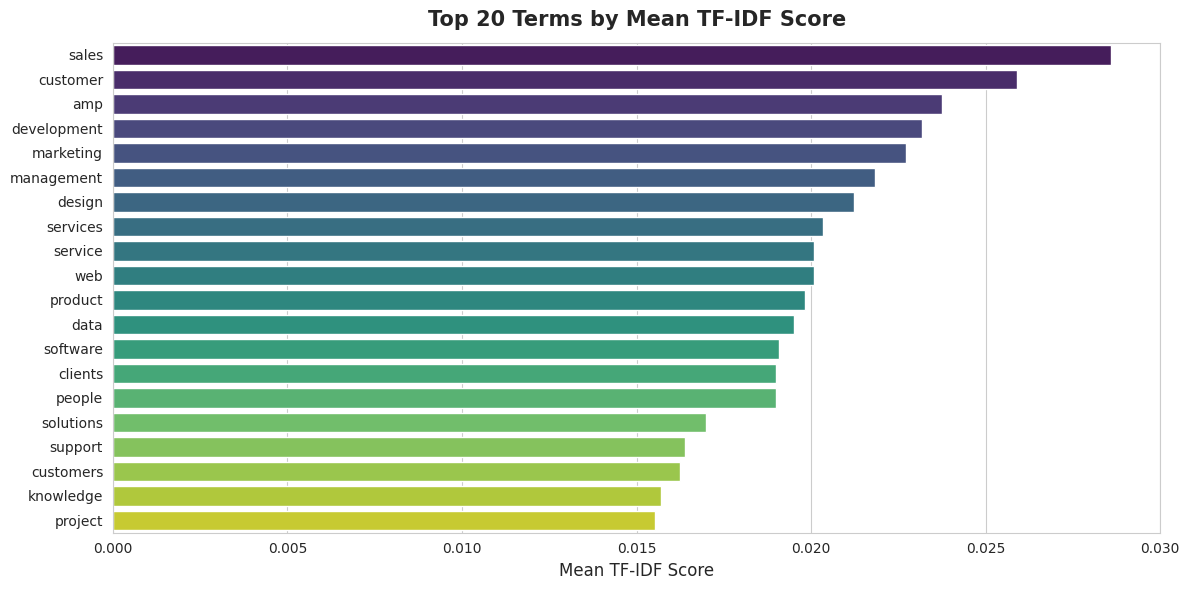

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf    = np.asarray(X.mean(axis=0)).flatten()
top_indices   = mean_tfidf.argsort()[::-1][:20]

top_tfidf_df = pd.DataFrame({
    "Term"        : feature_names[top_indices],
    "Mean TF-IDF" : mean_tfidf[top_indices]
})

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_tfidf_df, x="Mean TF-IDF", y="Term",
            palette="viridis", ax=ax)
ax.set_title("Top 20 Terms by Mean TF-IDF Score", **PLOT_TITLE_KWARGS)
ax.set_xlabel("Mean TF-IDF Score", **LABEL_KWARGS)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "tfidf_top_terms.png"), dpi=150)
plt.show()

 Save Cleaned Dataset

In [ ]:
output_path = os.path.join(OUTPUT_FOLDER, "cleaned_fake_job_dataset.csv")
df.to_csv(output_path, index=False)

print("=" * 60)
print("  CLEANED DATASET SAVED")
print(f"  Path  : {output_path}")
print(f"  Rows  : {len(df):,}")
print(f"  Cols  : {len(df.columns)}")
print(f"  Fitur engineered : {len(ENGINEERED_FEATURES)}")
print("=" * 60)

  CLEANED DATASET SAVED
  Path  : /content/drive/MyDrive/machine learning/cleaned_fake_job_dataset.csv
  Rows  : 17,880
  Cols  : 32
  Fitur engineered : 13


Project Insights Summary

In [ ]:
real_count = (df["fraudulent"] == 0).sum()
fake_count = (df["fraudulent"] == 1).sum()
total      = len(df)

print("=" * 60)
print("  PROJECT INSIGHTS")
print("=" * 60)

insights = {
    "1. Class Imbalance": (
        f"Dataset imbalanced — {real_count:,} real vs {fake_count:,} fake "
        f"({fake_count/total*100:.1f}% fake). SMOTE diperlukan saat modeling."
    ),
    "2. Text Length": (
        "Fake jobs punya teks lebih pendek. "
        "Real jobs lebih detail di company profile dan requirements."
    ),
    "3. Missing Info Signal": (
        f"Fake jobs lebih sering tidak mengisi company_profile "
        f"({df[df['fraudulent']==1]['has_company_profile'].mean()*100:.0f}% ada) "
        f"vs Real ({df[df['fraudulent']==0]['has_company_profile'].mean()*100:.0f}% ada). "
        "Ini sinyal kuat untuk klasifikasi."
    ),
    "4. Metadata Signal": (
        f"Fake jobs jarang punya company logo "
        f"({df[df['fraudulent']==1]['has_company_logo'].mean()*100:.0f}% ada) "
        f"vs Real ({df[df['fraudulent']==0]['has_company_logo'].mean()*100:.0f}% ada)."
    ),
    "5. Language Signals": (
        "Fake jobs pakai kata persuasif ('earn', 'income', 'home'). "
        "Real jobs pakai istilah teknis dan spesifik."
    ),
    "6. Feature Set": (
        f"TF-IDF (5000 fitur) + {len(ENGINEERED_FEATURES)} engineered features "
        f"({len(NUMERIC_FEATURES)} numerik + {len(BINARY_FEATURES)} biner)."
    ),
}

for title, detail in insights.items():
    print(f"\n  ▶ {title}")
    print(f"    {detail}")

print("\n" + "=" * 60)
print("  NEXT: Part 2 — Modeling & Evaluation")
print("=" * 60)

  PROJECT INSIGHTS

  ▶ 1. Class Imbalance
    Dataset imbalanced — 17,014 real vs 866 fake (4.8% fake). SMOTE diperlukan saat modeling.

  ▶ 2. Text Length
    Fake jobs punya teks lebih pendek. Real jobs lebih detail di company profile dan requirements.

  ▶ 3. Missing Info Signal
    Fake jobs lebih sering tidak mengisi company_profile (32% ada) vs Real (84% ada). Ini sinyal kuat untuk klasifikasi.

  ▶ 4. Metadata Signal
    Fake jobs jarang punya company logo (33% ada) vs Real (82% ada).

  ▶ 5. Language Signals
    Fake jobs pakai kata persuasif ('earn', 'income', 'home'). Real jobs pakai istilah teknis dan spesifik.

  ▶ 6. Feature Set
    TF-IDF (5000 fitur) + 13 engineered features (6 numerik + 7 biner).

  NEXT: Part 2 — Modeling & Evaluation


 Import Tambahan untuk Modeling

In [ ]:
from scipy.sparse import hstack, csr_matrix, issparse

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold
)
from imblearn.over_sampling import SMOTE

from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import LinearSVC
from sklearn.ensemble      import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes   import MultinomialNB
from sklearn.calibration   import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost tersedia")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost tidak tersedia — install: pip install xgboost")

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import joblib

try:
    import shap
    SHAP_AVAILABLE = True
    print(f"✅ SHAP tersedia (v{shap.__version__})")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP tidak tersedia — install: pip install shap")

print("\n✅ Semua library modeling berhasil diimport")

✅ XGBoost tersedia
✅ SHAP tersedia (v0.51.0)

✅ Semua library modeling berhasil diimport


 Gabungkan TF-IDF + Engineered Features

In [ ]:
# Konversi engineered features ke sparse matrix supaya bisa di-hstack
X_eng      = csr_matrix(df[ENGINEERED_FEATURES].values.astype(float))
X_combined = hstack([X, X_eng])

print("=" * 60)
print("  COMBINED FEATURE MATRIX")
print("=" * 60)
print(f"  TF-IDF Shape       : {X.shape}")
print(f"  Engineered Shape   : {X_eng.shape}")
print(f"  Combined Shape     : {X_combined.shape}")
print("=" * 60)

  COMBINED FEATURE MATRIX
  TF-IDF Shape       : (17880, 5000)
  Engineered Shape   : (17880, 13)
  Combined Shape     : (17880, 5013)


 Train-Test Split (Stratified 80/20)

In [ ]:
# stratify=y penting untuk menjaga proporsi kelas 95:5 di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("  TRAIN-TEST SPLIT RESULT")
print("=" * 60)
print(f"  X_train : {X_train.shape}  | Real: {(y_train==0).sum():,}  Fake: {(y_train==1).sum():,}")
print(f"  X_test  : {X_test.shape}   | Real: {(y_test==0).sum():,}   Fake: {(y_test==1).sum():,}")
print("=" * 60)

  TRAIN-TEST SPLIT RESULT
  X_train : (14304, 5013)  | Real: 13,611  Fake: 693
  X_test  : (3576, 5013)   | Real: 3,403   Fake: 173


 SMOTE: Menangani Class Imbalance

In [ ]:
# PENTING: SMOTE hanya diterapkan pada TRAINING SET, bukan test set.
# Kalau diterapkan sebelum split, sampel sintetis bisa bocor ke test → data leakage.
print(f"  Sebelum SMOTE — Real: {(y_train==0).sum():,}  Fake: {(y_train==1).sum():,}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"  Setelah SMOTE  — Real: {(y_train_sm==0).sum():,}  Fake: {(y_train_sm==1).sum():,}")

  Sebelum SMOTE — Real: 13,611  Fake: 693
  Setelah SMOTE  — Real: 13,611  Fake: 13,611


 Visualisasi Distribusi Before/After SMOTE

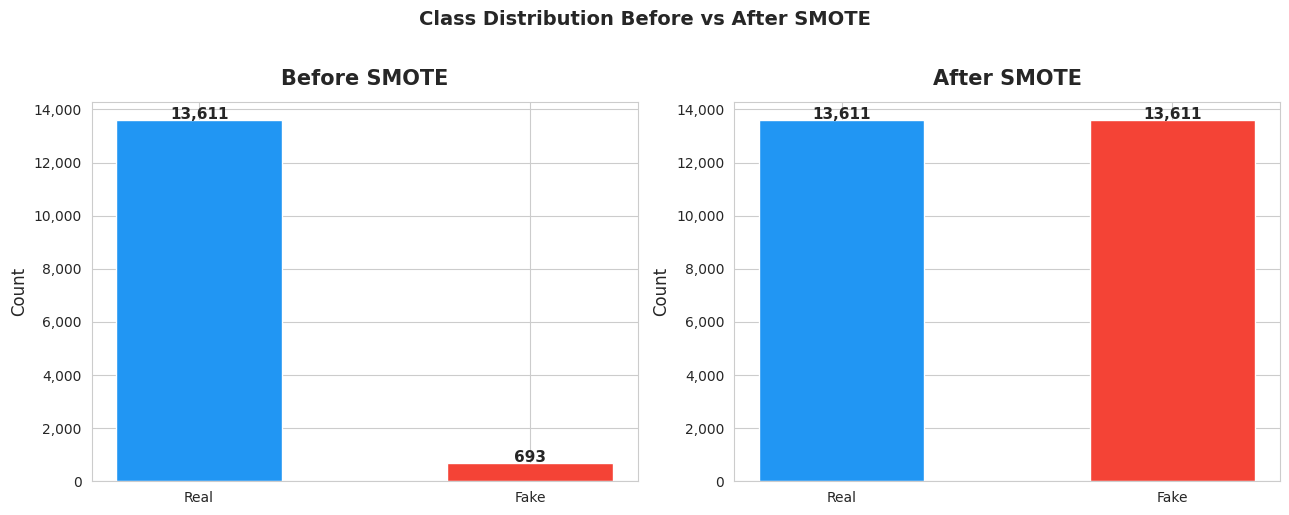

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ["Real", "Fake"]
colors = [COLOR_REAL, COLOR_FAKE]

for ax, counts, title in zip(
    axes,
    [(y_train==0).sum(), (y_train==1).sum()],
    ["Before SMOTE", "After SMOTE"]
):
    if title == "After SMOTE":
        counts = [(y_train_sm==0).sum(), (y_train_sm==1).sum()]
    else:
        counts = [(y_train==0).sum(), (y_train==1).sum()]

    bars = ax.bar(labels, counts, color=colors, edgecolor="white", width=0.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+30,
                f"{cnt:,}", ha="center", fontsize=11, fontweight="bold")
    ax.set_title(title, **PLOT_TITLE_KWARGS)
    ax.set_ylabel("Count", **LABEL_KWARGS)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

plt.suptitle("Class Distribution Before vs After SMOTE",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "smote_distribution.png"), dpi=150)
plt.show()

 Helper Functions (Evaluasi & Confusion Matrix)

In [ ]:
def make_non_negative(mat):
    """Shift matrix agar semua nilai >= 0 (diperlukan Multinomial NB)."""
    if issparse(mat):
        mat = mat.toarray()
    mat = mat - mat.min(axis=0, keepdims=True)
    return csr_matrix(mat)


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Latih model dan kembalikan dict metrik lengkap."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        sc     = model.decision_function(X_te)
        y_prob = (sc - sc.min()) / (sc.max() - sc.min() + 1e-9)
    else:
        y_prob = y_pred.astype(float)

    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_te, y_pred, zero_division=0), 4),
        "F1-Score" : round(f1_score(y_te, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_te, y_prob), 4),
        "_model"   : model,
        "_y_pred"  : y_pred,
        "_y_prob"  : y_prob,
    }


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", ax=None):
    """Heatmap confusion matrix dengan persentase."""
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([
        [f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)" for j in range(2)]
        for i in range(2)
    ])
    own = ax is None
    if own: _, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                xticklabels=["Real","Fake"], yticklabels=["Real","Fake"],
                linewidths=0.5, linecolor="white", ax=ax,
                annot_kws={"size":11})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    if own: plt.tight_layout(); plt.show()


print("✅ Helper functions siap digunakan")

✅ Helper functions siap digunakan


 Train Semua Model

In [ ]:
print("=" * 60)
print("  TRAINING ALL MODELS ...")
print("=" * 60)

results = []

# Multinomial NB butuh input non-negatif
X_train_nb = make_non_negative(X_train_sm)
X_test_nb  = make_non_negative(X_test)

# 1. Logistic Regression
print("  [1/5] Logistic Regression ...")
results.append(evaluate_model(
    "Logistic Regression",
    LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs",
                       class_weight="balanced", random_state=42),
    X_train_sm, y_train_sm, X_test, y_test
))

# 2. Linear SVM (CalibratedCV agar punya predict_proba)
print("  [2/5] Linear SVM ...")
results.append(evaluate_model(
    "Linear SVM",
    CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, class_weight="balanced"), cv=3),
    X_train_sm, y_train_sm, X_test, y_test
))

# 3. Random Forest
print("  [3/5] Random Forest ...")
results.append(evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, class_weight="balanced",
                           random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm, X_test, y_test
))

# 4. XGBoost
if XGBOOST_AVAILABLE:
    print("  [4/5] XGBoost ...")
    scale_pos = (y_train_sm==0).sum() / (y_train_sm==1).sum()
    results.append(evaluate_model(
        "XGBoost",
        XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                      scale_pos_weight=scale_pos, use_label_encoder=False,
                      eval_metric="logloss", random_state=42, n_jobs=-1),
        X_train_sm, y_train_sm, X_test, y_test
    ))
else:
    print("  [4/5] XGBoost dilewati.")

# 5. Multinomial NB
print("  [5/5] Multinomial Naive Bayes ...")
results.append(evaluate_model(
    "Multinomial NB",
    MultinomialNB(alpha=0.1),
    X_train_nb, y_train_sm, X_test_nb, y_test
))

print("\n✅ Semua model selesai dilatih!")

  TRAINING ALL MODELS ...
  [1/5] Logistic Regression ...
  [2/5] Linear SVM ...
  [3/5] Random Forest ...
  [4/5] XGBoost ...
  [5/5] Multinomial Naive Bayes ...

✅ Semua model selesai dilatih!


 Tabel Perbandingan Semua Model

In [ ]:
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in results
]).set_index("Model").sort_values("F1-Score", ascending=False)

display(
    metrics_df.style
        .background_gradient(cmap="YlGn",  subset=["F1-Score","ROC-AUC"])
        .background_gradient(cmap="Blues", subset=["Accuracy","Precision","Recall"])
        .format("{:.4f}")
        .set_caption("Model Comparison — sorted by F1-Score")
)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Linear SVM,0.9849,0.9161,0.7572,0.8291,0.9916
XGBoost,0.9852,0.9412,0.7399,0.8285,0.9896
Random Forest,0.9843,0.9916,0.6821,0.8082,0.9918
Logistic Regression,0.9376,0.4309,0.9017,0.5832,0.9799
Multinomial NB,0.8515,0.2220,0.8266,0.3501,0.9097


 Classification Report Semua Model

In [ ]:
for r in results:
    print(f"\n  {'='*50}")
    print(f"  {r['Model']}")
    print(f"  {'='*50}")
    for line in classification_report(
        y_test, r["_y_pred"], target_names=["Real","Fake"]
    ).split("\n"):
        print("  " + line)


  Logistic Regression
                precision    recall  f1-score   support
  
          Real       0.99      0.94      0.97      3403
          Fake       0.43      0.90      0.58       173
  
      accuracy                           0.94      3576
     macro avg       0.71      0.92      0.77      3576
  weighted avg       0.97      0.94      0.95      3576
  

  Linear SVM
                precision    recall  f1-score   support
  
          Real       0.99      1.00      0.99      3403
          Fake       0.92      0.76      0.83       173
  
      accuracy                           0.98      3576
     macro avg       0.95      0.88      0.91      3576
  weighted avg       0.98      0.98      0.98      3576
  

  Random Forest
                precision    recall  f1-score   support
  
          Real       0.98      1.00      0.99      3403
          Fake       0.99      0.68      0.81       173
  
      accuracy                           0.98      3576
     macro avg       0.99 

 Confusion Matrix Semua Model

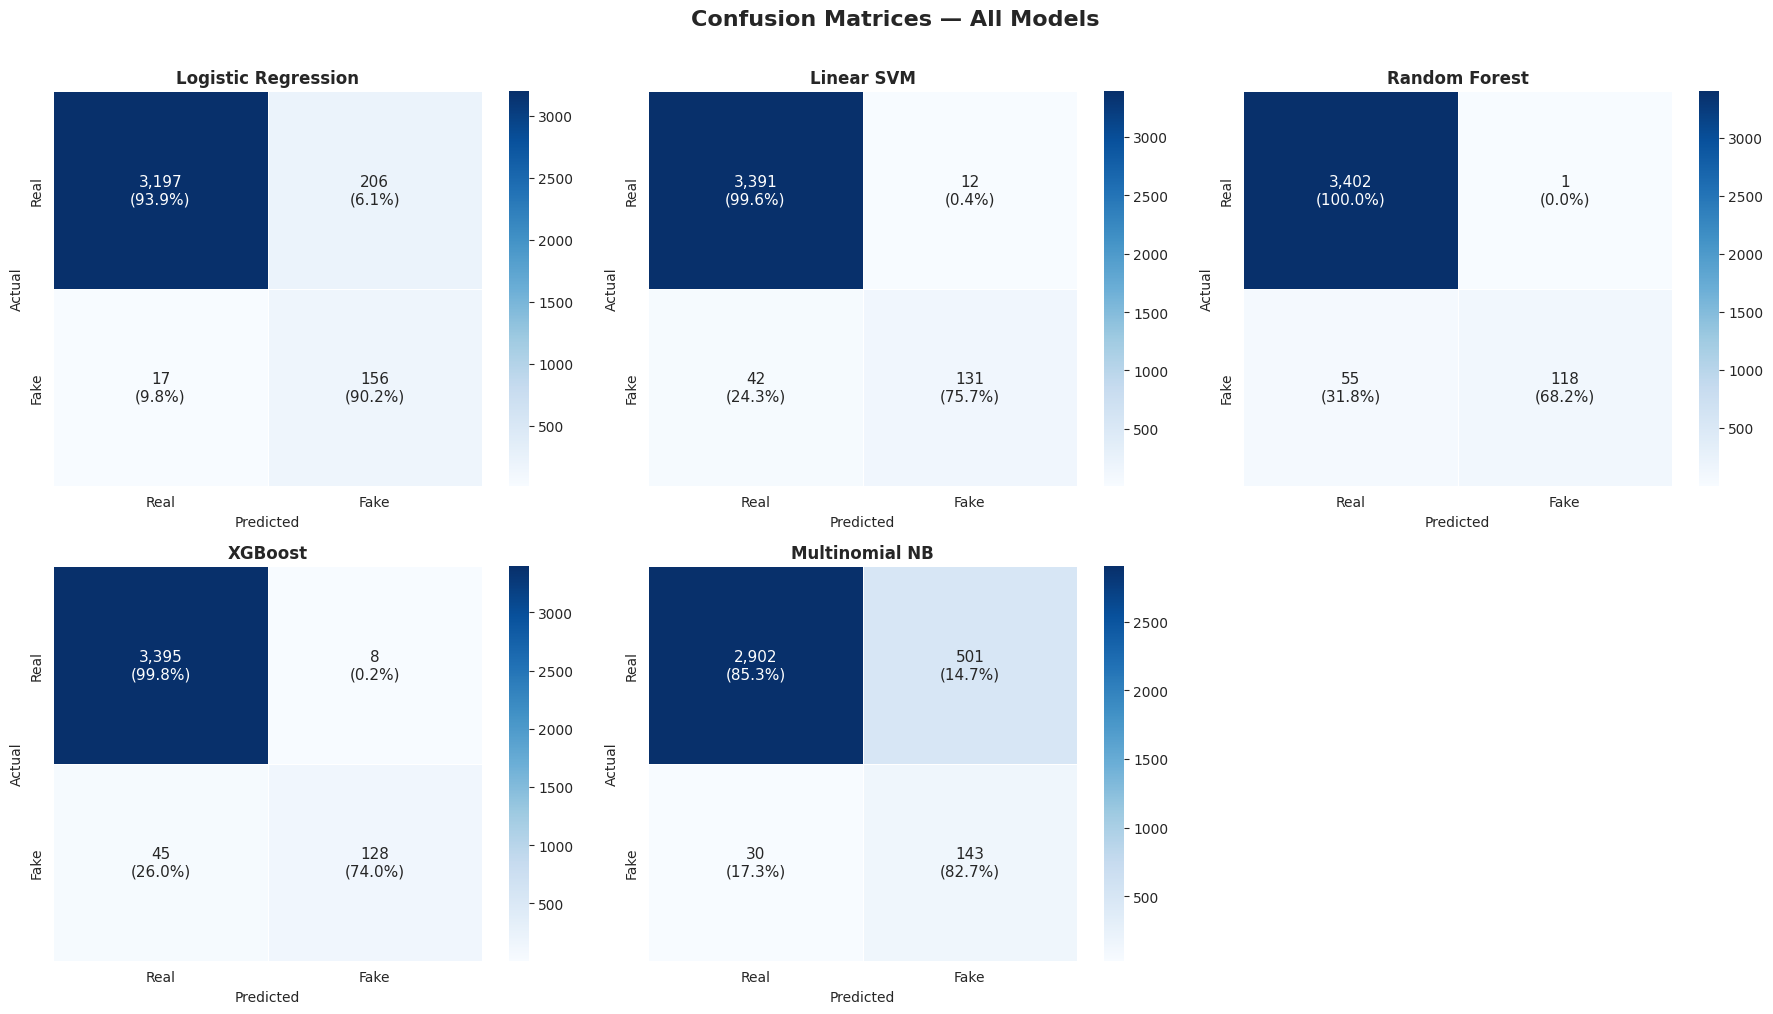

In [ ]:
n_cols    = 3
n_rows    = (len(results) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes_flat = axes.flatten() if len(results) > 1 else [axes]

for i, r in enumerate(results):
    plot_confusion_matrix(y_test, r["_y_pred"], title=r["Model"], ax=axes_flat[i])

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Confusion Matrices — All Models",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()

 ROC Curve Perbandingan

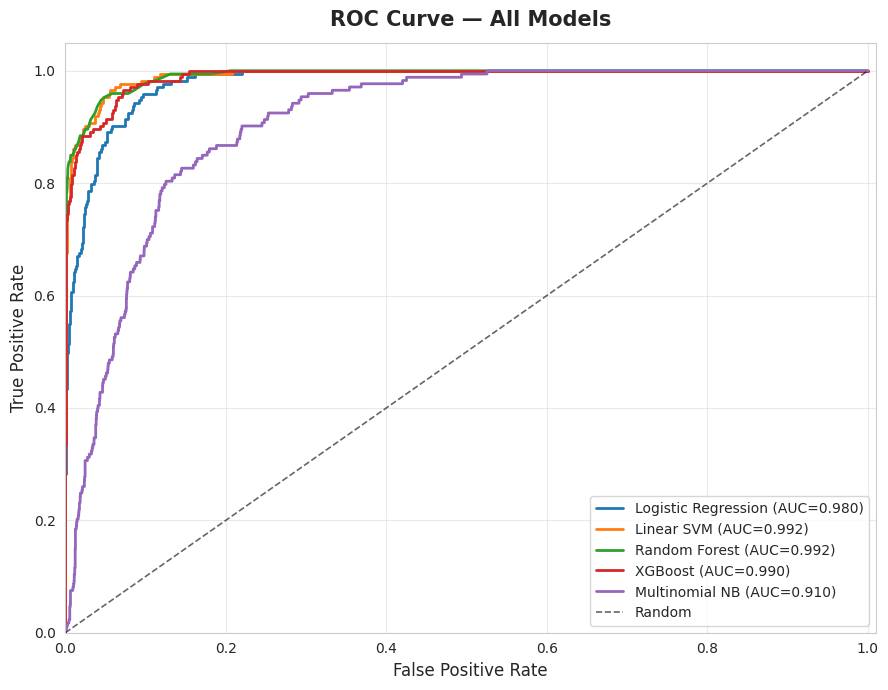

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("tab10", n_colors=len(results))

for i, r in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, r["_y_prob"])
    ax.plot(fpr, tpr, lw=2, color=palette[i],
            label=f"{r['Model']} (AUC={auc(fpr,tpr):.3f})")

ax.plot([0,1],[0,1],"k--",lw=1.2,alpha=0.6,label="Random")
ax.set_xlim([0,1.01]); ax.set_ylim([0,1.05])
ax.set_xlabel("False Positive Rate", **LABEL_KWARGS)
ax.set_ylabel("True Positive Rate",  **LABEL_KWARGS)
ax.set_title("ROC Curve — All Models", **PLOT_TITLE_KWARGS)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, "roc_curves.png"), dpi=150)
plt.show()

 Barplot F1-Score & ROC-AUC

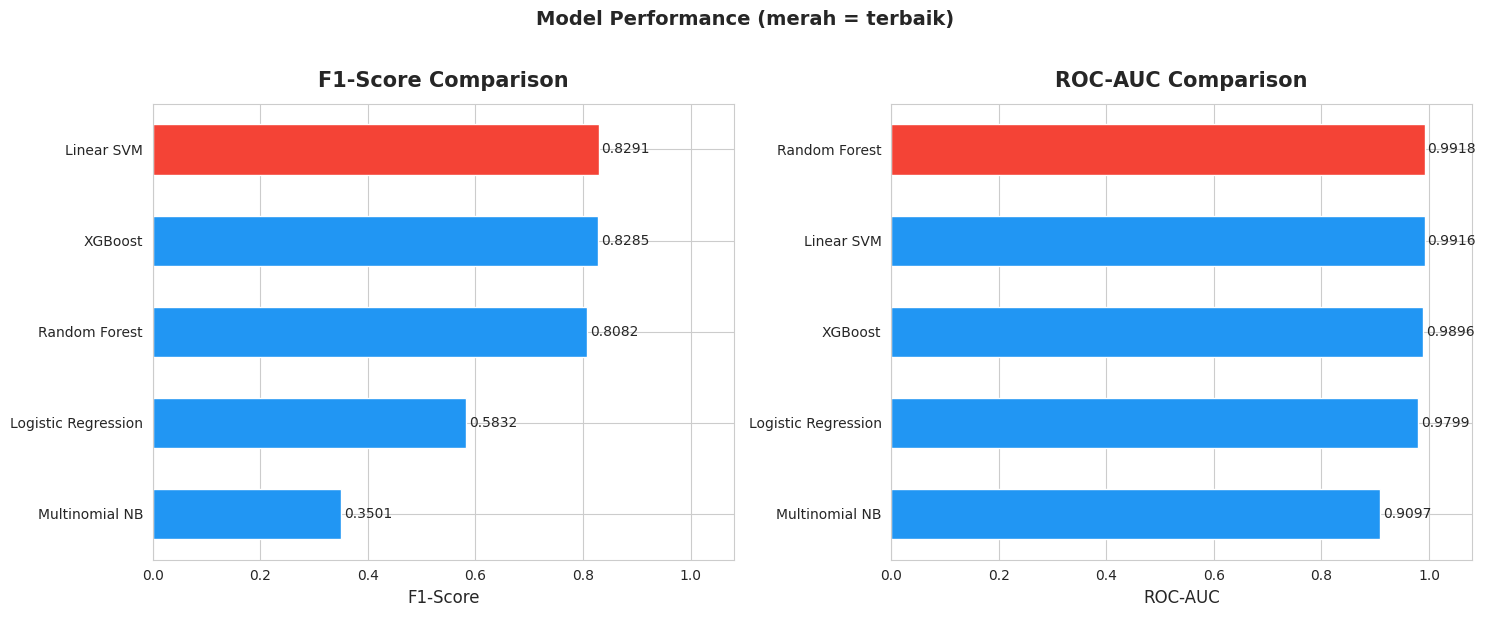


🏆 Model terbaik : Linear SVM
   F1-Score : 0.8291
   ROC-AUC  : 0.9916


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def bar_colors(series):
    cols = [COLOR_REAL] * len(series)
    cols[series.values.argmax()] = COLOR_FAKE
    return cols

for ax, metric, label in zip(
    axes,
    ["F1-Score", "ROC-AUC"],
    ["F1-Score", "ROC-AUC"]
):
    df_sorted = metrics_df.sort_values(metric)
    ax.barh(df_sorted.index, df_sorted[metric],
            color=bar_colors(df_sorted[metric]),
            edgecolor="white", height=0.55)
    ax.set_title(f"{label} Comparison", **PLOT_TITLE_KWARGS)
    ax.set_xlabel(label, **LABEL_KWARGS)
    ax.set_xlim(0, 1.08)
    for i, v in enumerate(df_sorted[metric]):
        ax.text(v+0.005, i, f"{v:.4f}", va="center", fontsize=10)

plt.suptitle("Model Performance (merah = terbaik)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

best_model_name = metrics_df["F1-Score"].idxmax()
best_result     = next(r for r in results if r["Model"] == best_model_name)
print(f"\n🏆 Model terbaik : {best_model_name}")
print(f"   F1-Score : {best_result['F1-Score']:.4f}")
print(f"   ROC-AUC  : {best_result['ROC-AUC']:.4f}")

 Regularized Models + Honest Evaluation

In [ ]:
# Train F1 dihitung di X_train ORIGINAL (sebelum SMOTE) — honest evaluation.
# Model dilatih di SMOTE data, tapi dievaluasi train-nya di data asli.
print("=" * 60)
print("  REGULARIZED MODELS — HONEST EVAL")
print("=" * 60)

regularized_models = {
    "LR (C=0.1)"    : LogisticRegression(C=0.1, max_iter=1000, solver="lbfgs",
                                          class_weight="balanced", random_state=42),
    "SVM (C=0.1)"   : CalibratedClassifierCV(
                          LinearSVC(C=0.1, max_iter=2000, class_weight="balanced"), cv=3),
    "RF (depth=10)" : RandomForestClassifier(n_estimators=100, max_depth=10,
                                              min_samples_split=10, min_samples_leaf=5,
                                              class_weight="balanced",
                                              random_state=42, n_jobs=-1),
    "NB (alpha=1.0)": MultinomialNB(alpha=1.0),
}

if XGBOOST_AVAILABLE:
    scale_pos = (y_train_sm==0).sum() / (y_train_sm==1).sum()
    regularized_models["XGBoost (reg)"] = XGBClassifier(
        n_estimators=150, learning_rate=0.05, max_depth=4,
        reg_alpha=0.5, reg_lambda=1.0, subsample=0.8,
        colsample_bytree=0.8, scale_pos_weight=scale_pos,
        use_label_encoder=False, eval_metric="logloss",
        random_state=42, n_jobs=-1
    )

reg_results = []

for name, model in regularized_models.items():
    is_nb   = isinstance(model, MultinomialNB)
    X_tr    = X_train_nb if is_nb else X_train_sm
    X_tr_ev = make_non_negative(X_train) if is_nb else X_train
    X_te    = X_test_nb  if is_nb else X_test

    model.fit(X_tr, y_train_sm)
    y_tr_pred = model.predict(X_tr_ev)
    y_te_pred = model.predict(X_te)
    y_te_prob = (model.predict_proba(X_te)[:,1] if hasattr(model,"predict_proba")
                 else (lambda sc: (sc-sc.min())/(sc.max()-sc.min()+1e-9))(
                     model.decision_function(X_te)))

    train_f1 = f1_score(y_train, y_tr_pred, zero_division=0)
    test_f1  = f1_score(y_test,  y_te_pred, zero_division=0)
    gap      = train_f1 - test_f1

    reg_results.append({
        "Model"     : name,
        "Train F1"  : round(train_f1, 4),
        "Test F1"   : round(test_f1, 4),
        "Gap"       : round(gap, 4),
        "Test Acc"  : round(accuracy_score(y_test, y_te_pred), 4),
        "Test Prec" : round(precision_score(y_test, y_te_pred, zero_division=0), 4),
        "Test Rec"  : round(recall_score(y_test, y_te_pred, zero_division=0), 4),
        "Test AUC"  : round(roc_auc_score(y_test, y_te_prob), 4),
        "_model": model, "_y_pred": y_te_pred, "_y_prob": y_te_prob,
    })

    status = "✅ HEALTHY" if gap < 0.05 else ("⚠️ WARNING" if gap < 0.10 else "❌ OVERFIT")
    print(f"  {name:<20} Train={train_f1:.4f}  Test={test_f1:.4f}  Gap={gap:+.4f}  {status}")

  REGULARIZED MODELS — HONEST EVAL
  LR (C=0.1)           Train=0.4881  Test=0.4630  Gap=+0.0252  ✅ HEALTHY
  SVM (C=0.1)          Train=0.8613  Test=0.7796  Gap=+0.0818  ⚠️ WARNING
  RF (depth=10)        Train=0.7363  Test=0.6596  Gap=+0.0767  ⚠️ WARNING
  NB (alpha=1.0)       Train=0.2973  Test=0.3090  Gap=-0.0118  ✅ HEALTHY
  XGBoost (reg)        Train=0.7398  Test=0.6562  Gap=+0.0836  ⚠️ WARNING



 Tabel Hasil Regularized Models

In [ ]:
reg_df = pd.DataFrame([
    {k:v for k,v in r.items() if not k.startswith("_")}
    for r in reg_results
]).sort_values("Test F1", ascending=False).reset_index(drop=True)

reg_df["Composite"] = (reg_df["Test F1"] - 0.5 * reg_df["Gap"]).round(4)

display(
    reg_df.style
        .background_gradient(cmap="YlGn",   subset=["Test F1","Composite"])
        .background_gradient(cmap="Reds_r", subset=["Gap"])
        .format("{:.4f}", subset=reg_df.columns[1:])
        .set_caption("Composite = Test F1 − 0.5×Gap  |  Train F1 di data ORIGINAL (honest eval)")
)

,Model,Train F1,Test F1,Gap,Test Acc,Test Prec,Test Rec,Test AUC,Composite
0,SVM (C=0.1),0.8613,0.7796,0.0818,0.9771,0.7286,0.8382,0.9907,0.7387
1,RF (depth=10),0.7363,0.6596,0.0767,0.9642,0.6108,0.7168,0.9760,0.6212
2,XGBoost (reg),0.7398,0.6562,0.0836,0.9692,0.7143,0.6069,0.9676,0.6144
3,LR (C=0.1),0.4881,0.4630,0.0252,0.9027,0.3158,0.8671,0.9650,0.4504
4,NB (alpha=1.0),0.2973,0.3090,-0.0118,0.8224,0.1903,0.8208,0.8916,0.3149


 Visualisasi Overfitting Gap

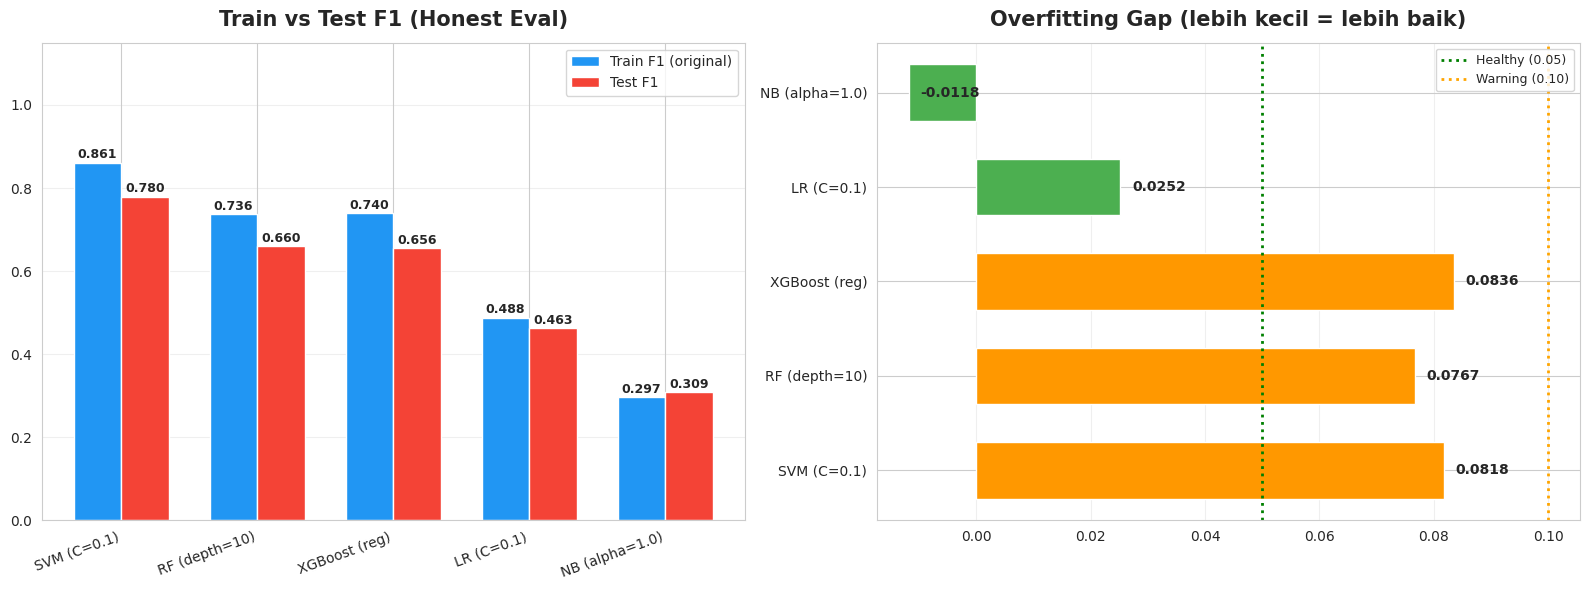

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(reg_df))
w = 0.35

axes[0].bar(x-w/2, reg_df["Train F1"], w, label="Train F1 (original)",
            color=COLOR_REAL, edgecolor="white")
axes[0].bar(x+w/2, reg_df["Test F1"],  w, label="Test F1",
            color=COLOR_FAKE, edgecolor="white")
for i,(tr,te) in enumerate(zip(reg_df["Train F1"],reg_df["Test F1"])):
    axes[0].text(i-w/2, tr+0.01, f"{tr:.3f}", ha="center", fontsize=9, fontweight="bold")
    axes[0].text(i+w/2, te+0.01, f"{te:.3f}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(reg_df["Model"], rotation=20, ha="right")
axes[0].set_title("Train vs Test F1 (Honest Eval)", **PLOT_TITLE_KWARGS)
axes[0].legend(); axes[0].set_ylim(0,1.15); axes[0].grid(True,alpha=0.3,axis="y")

gap_colors = ["#4CAF50" if g<0.05 else "#FF9800" if g<0.10 else "#F44336"
               for g in reg_df["Gap"]]
axes[1].barh(reg_df["Model"], reg_df["Gap"], color=gap_colors, edgecolor="white", height=0.6)
for i,g in enumerate(reg_df["Gap"]):
    axes[1].text(g+0.002, i, f"{g:.4f}", va="center", fontsize=10, fontweight="bold")
axes[1].axvline(0.05, color="green",  ls=":",  lw=2, label="Healthy (0.05)")
axes[1].axvline(0.10, color="orange", ls=":",  lw=2, label="Warning (0.10)")
axes[1].set_title("Overfitting Gap (lebih kecil = lebih baik)", **PLOT_TITLE_KWARGS)
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.3,axis="x")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER,"overfitting_analysis.png"),dpi=150,bbox_inches="tight")
plt.show()

 SVM C Sweep: Cari Sweet Spot

In [ ]:
print("=" * 60)
print("  SVM C SWEEP")
print("=" * 60)

C_VALUES      = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 2.0]
sweep_records = []

for C in C_VALUES:
    svm = CalibratedClassifierCV(
        LinearSVC(C=C, max_iter=3000, class_weight="balanced"), cv=3)
    svm.fit(X_train_sm, y_train_sm)

    y_tr_pred = svm.predict(X_train)
    y_te_pred = svm.predict(X_test)
    y_te_prob = svm.predict_proba(X_test)[:,1]

    train_f1  = f1_score(y_train, y_tr_pred, zero_division=0)
    test_f1   = f1_score(y_test,  y_te_pred, zero_division=0)
    gap       = train_f1 - test_f1
    composite = test_f1 - 0.5 * gap

    sweep_records.append({
        "C": C, "Train F1": round(train_f1,4), "Test F1": round(test_f1,4),
        "Gap": round(gap,4),
        "Precision": round(precision_score(y_test,y_te_pred,zero_division=0),4),
        "Recall"   : round(recall_score(y_test,y_te_pred,zero_division=0),4),
        "AUC"      : round(roc_auc_score(y_test,y_te_prob),4),
        "Composite": round(composite,4),
        "_model": svm, "_y_pred": y_te_pred, "_y_prob": y_te_prob,
    })

    status = "✅" if gap < 0.05 else ("⚠️" if gap < 0.10 else "❌")
    print(f"  C={C:<5}  Train={train_f1:.4f}  Test={test_f1:.4f}  "
          f"Gap={gap:+.4f}  Composite={composite:.4f}  {status}")

  SVM C SWEEP
  C=0.05   Train=0.7909  Test=0.7251  Gap=+0.0659  Composite=0.6921  ⚠️
  C=0.1    Train=0.8613  Test=0.7796  Gap=+0.0818  Composite=0.7387  ⚠️
  C=0.2    Train=0.9343  Test=0.8294  Gap=+0.1049  Composite=0.7769  ❌
  C=0.3    Train=0.9568  Test=0.8364  Gap=+0.1204  Composite=0.7762  ❌
  C=0.5    Train=0.9759  Test=0.8328  Gap=+0.1430  Composite=0.7613  ❌
  C=0.7    Train=0.9829  Test=0.8328  Gap=+0.1501  Composite=0.7577  ❌
  C=1.0    Train=0.9837  Test=0.8291  Gap=+0.1545  Composite=0.7518  ❌
  C=2.0    Train=0.9872  Test=0.8269  Gap=+0.1603  Composite=0.7468  ❌


 C Sweep: Tabel & Pilih Sweet Spot

In [ ]:
sweep_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith("_")}
                          for r in sweep_records])

display(
    sweep_df.style
        .background_gradient(cmap="YlGn",   subset=["Test F1","Composite"])
        .background_gradient(cmap="Reds_r", subset=["Gap"])
        .highlight_max(subset=["Composite"], color="#C8E6C9")
        .format("{:.4f}", subset=sweep_df.columns[1:])
        .set_caption("Sweet spot: Test F1 tinggi + Gap kecil")
)

best_sweep_idx   = sweep_df["Composite"].idxmax()
best_sweep_row   = sweep_df.iloc[best_sweep_idx]
best_C           = best_sweep_row["C"]
best_sweep_model = sweep_records[best_sweep_idx]["_model"]

# Ambil prob langsung dari sweep_records (lebih aman dari variabel terpisah)
best_sweep_prob  = sweep_records[best_sweep_idx]["_y_prob"]

print(f"\n🎯 Sweet spot: C = {best_C}")
print(f"   Test F1  : {best_sweep_row['Test F1']:.4f}")
print(f"   Gap      : {best_sweep_row['Gap']:.4f}")
print(f"   AUC      : {best_sweep_row['AUC']:.4f}")

,C,Train F1,Test F1,Gap,Precision,Recall,AUC,Composite
0,0.050000,0.7909,0.7251,0.0659,0.6261,0.8613,0.9881,0.6921
1,0.100000,0.8613,0.7796,0.0818,0.7286,0.8382,0.9907,0.7387
2,0.200000,0.9343,0.8294,0.1049,0.8443,0.8150,0.9918,0.7769
3,0.300000,0.9568,0.8364,0.1204,0.8790,0.7977,0.9919,0.7762
4,0.500000,0.9759,0.8328,0.1430,0.9167,0.7630,0.9919,0.7613
5,0.700000,0.9829,0.8328,0.1501,0.9167,0.7630,0.9914,0.7577
6,1.000000,0.9837,0.8291,0.1545,0.9161,0.7572,0.9916,0.7518
7,2.000000,0.9872,0.8269,0.1603,0.9281,0.7457,0.9912,0.7468



🎯 Sweet spot: C = 0.2
   Test F1  : 0.8294
   Gap      : 0.1049
   AUC      : 0.9918


 C Sweep Visualization

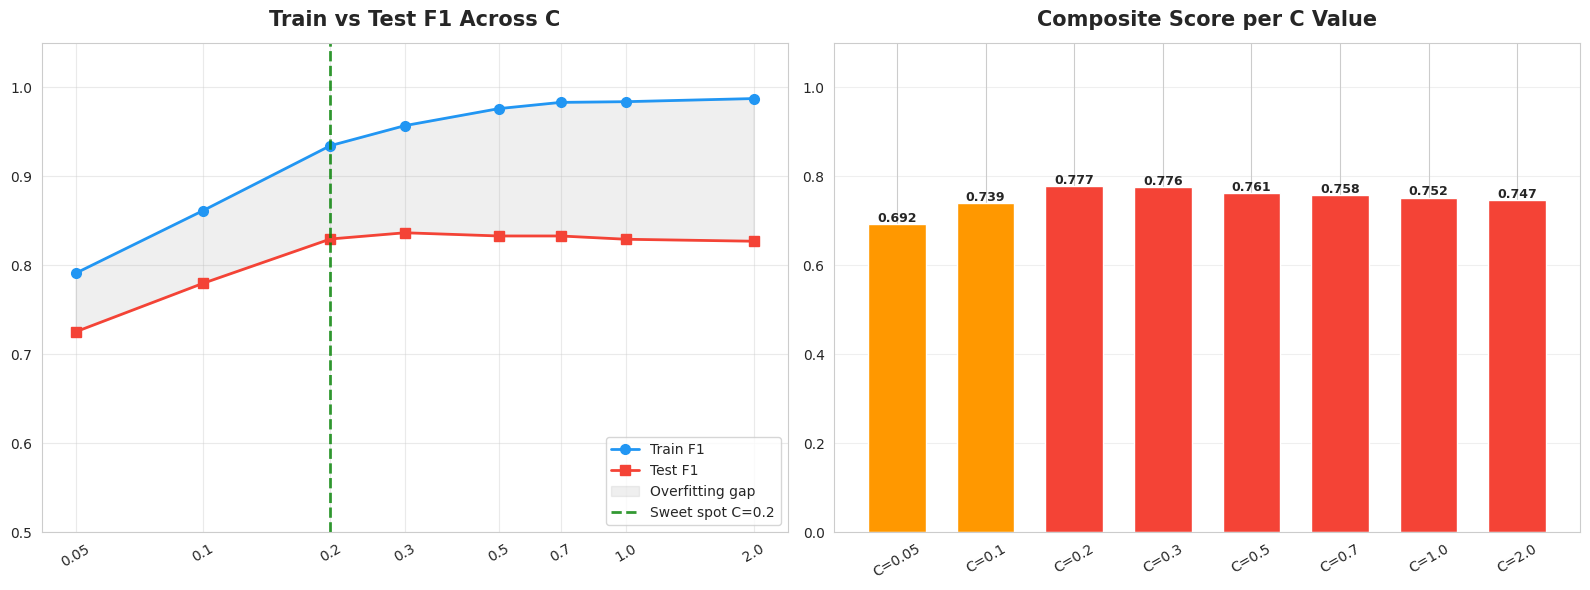

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_log = np.log10(sweep_df["C"])

axes[0].plot(x_log, sweep_df["Train F1"], "o-", color=COLOR_REAL, lw=2,
             label="Train F1", markersize=7)
axes[0].plot(x_log, sweep_df["Test F1"],  "s-", color=COLOR_FAKE, lw=2,
             label="Test F1",  markersize=7)
axes[0].fill_between(x_log, sweep_df["Train F1"], sweep_df["Test F1"],
                     alpha=0.12, color="gray", label="Overfitting gap")
axes[0].axvline(np.log10(best_C), color="green", ls="--", lw=2, alpha=0.8,
                label=f"Sweet spot C={best_C}")
axes[0].set_xticks(x_log)
axes[0].set_xticklabels([str(c) for c in sweep_df["C"]], rotation=30)
axes[0].set_title("Train vs Test F1 Across C", **PLOT_TITLE_KWARGS)
axes[0].legend(loc="lower right"); axes[0].set_ylim(0.5,1.05)
axes[0].grid(True, alpha=0.4)

bar_c = ["#4CAF50" if g<0.05 else "#FF9800" if g<0.10 else "#F44336"
          for g in sweep_df["Gap"]]
axes[1].bar(range(len(sweep_df)), sweep_df["Composite"],
            color=bar_c, edgecolor="white", width=0.65)
for i,(comp,c) in enumerate(zip(sweep_df["Composite"],sweep_df["C"])):
    axes[1].text(i, comp+0.005, f"{comp:.3f}", ha="center", fontsize=9, fontweight="bold")
axes[1].set_xticks(range(len(sweep_df)))
axes[1].set_xticklabels([f"C={c}" for c in sweep_df["C"]], rotation=30)
axes[1].set_title("Composite Score per C Value", **PLOT_TITLE_KWARGS)
axes[1].grid(True, alpha=0.3, axis="y"); axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER,"svm_c_sweep.png"),dpi=150,bbox_inches="tight")
plt.show()

 Threshold Optimization via PR Curve

In [ ]:
probs    = best_sweep_prob
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, probs)
avg_prec = average_precision_score(y_test, probs)

prec_arr = prec_arr[:-1]; rec_arr = rec_arr[:-1]

f1_arr = 2*prec_arr*rec_arr / (prec_arr+rec_arr+1e-9)
f2_arr = 5*prec_arr*rec_arr / (4*prec_arr+rec_arr+1e-9)

thr_f1_opt = thr_arr[f1_arr.argmax()]
thr_f2_opt = thr_arr[f2_arr.argmax()]

def eval_at_thr(y_true, y_prob, thr):
    yp = (y_prob >= thr).astype(int)
    return {
        "Threshold": round(thr,4),
        "Precision": round(precision_score(y_true,yp,zero_division=0),4),
        "Recall"   : round(recall_score(y_true,yp,zero_division=0),4),
        "F1"       : round(f1_score(y_true,yp,zero_division=0),4),
        "F2"       : round(fbeta_score(y_true,yp,beta=2,zero_division=0),4),
        "Accuracy" : round(accuracy_score(y_true,yp),4),
    }

res_default = eval_at_thr(y_test, probs, 0.5)
res_f1_opt  = eval_at_thr(y_test, probs, thr_f1_opt)
res_f2_opt  = eval_at_thr(y_test, probs, thr_f2_opt)

thr_cmp = pd.DataFrame(
    [res_default, res_f1_opt, res_f2_opt],
    index=["Default (0.50)", f"F1-Optimal ({thr_f1_opt:.3f})",
           f"F2-Optimal ({thr_f2_opt:.3f})"]
)

print("=" * 60)
print("  THRESHOLD COMPARISON")
print("=" * 60)
display(
    thr_cmp.style
        .highlight_max(subset=["F1"], color="#C8E6C9")
        .highlight_max(subset=["F2"], color="#BBDEFB")
        .highlight_max(subset=["Recall"], color="#F8BBD0")
        .format("{:.4f}")
)

# Pilih threshold final
FINAL_THRESHOLD = thr_f2_opt if res_f2_opt["Precision"] >= 0.60 else thr_f1_opt
y_pred_final    = (probs >= FINAL_THRESHOLD).astype(int)

print(f"\n✅ Threshold final: {FINAL_THRESHOLD:.4f}")
print(f"   (F2-optimal jika Precision >= 0.60, else F1-optimal)")

print("\n  MANUAL THRESHOLD SWEEP")
print("  " + "-"*45)
for thr in [0.15, 0.18, 0.20, 0.22, 0.25, 0.27]:
    res = eval_at_thr(y_test, probs, thr)
    print(f"  thr={thr:.2f}  F1={res['F1']:.4f}  "
          f"Recall={res['Recall']:.4f}  Prec={res['Precision']:.4f}")

  THRESHOLD COMPARISON


,Threshold,Precision,Recall,F1,F2,Accuracy
Default (0.50),0.5000,0.8443,0.8150,0.8294,0.8207,0.9838
F1-Optimal (0.702),0.7016,0.8940,0.7803,0.8333,0.8007,0.9849
F2-Optimal (0.270),0.2698,0.7749,0.8555,0.8132,0.8381,0.9810



✅ Threshold final: 0.2698
   (F2-optimal jika Precision >= 0.60, else F1-optimal)

  MANUAL THRESHOLD SWEEP
  ---------------------------------------------
  thr=0.15  F1=0.7812  Recall=0.8671  Prec=0.7109
  thr=0.18  F1=0.7851  Recall=0.8555  Prec=0.7255
  thr=0.20  F1=0.7914  Recall=0.8555  Prec=0.7363
  thr=0.22  F1=0.7957  Recall=0.8555  Prec=0.7437
  thr=0.25  F1=0.8065  Recall=0.8555  Prec=0.7629
  thr=0.27  F1=0.8099  Recall=0.8497  Prec=0.7737


PR Curve & Metrics vs Threshold

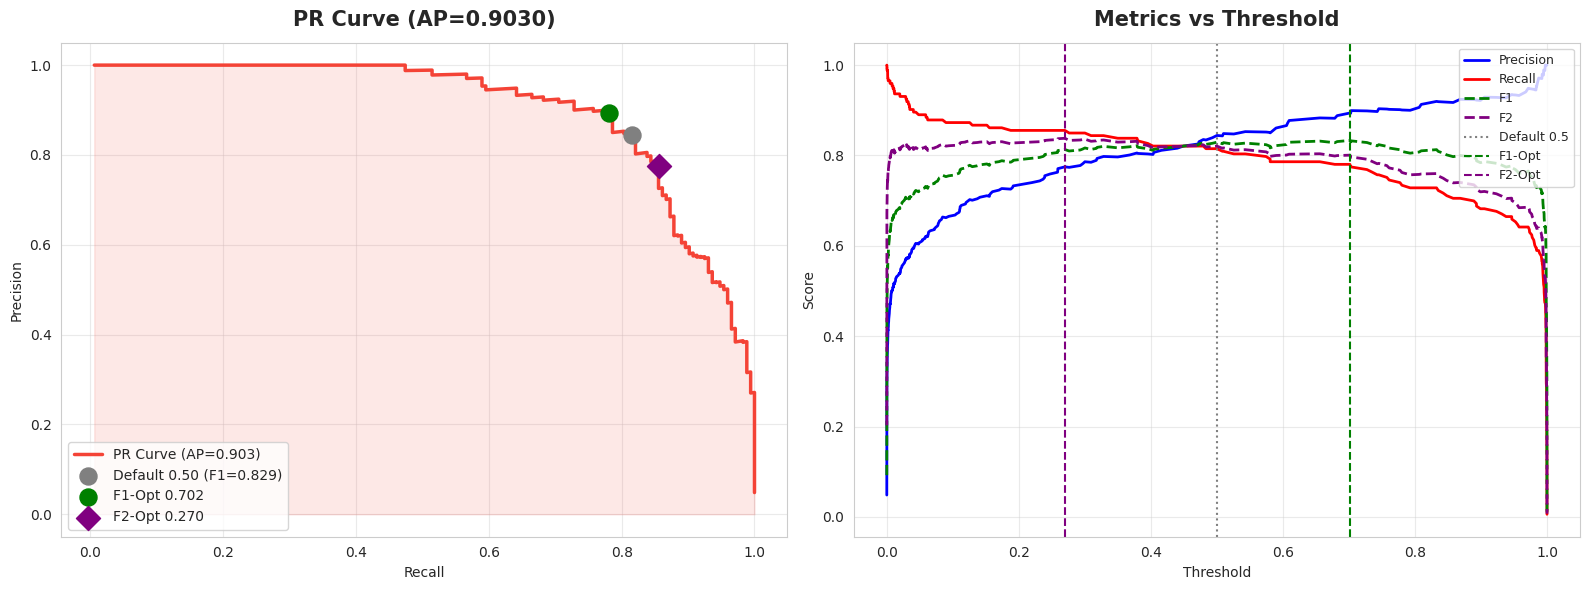

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR Curve
axes[0].plot(rec_arr, prec_arr, color=COLOR_FAKE, lw=2.5,
             label=f"PR Curve (AP={avg_prec:.3f})")
axes[0].fill_between(rec_arr, prec_arr, alpha=0.12, color=COLOR_FAKE)
axes[0].scatter(res_default["Recall"], res_default["Precision"],
                s=150, color="gray",   zorder=5, label=f"Default 0.50 (F1={res_default['F1']:.3f})")
axes[0].scatter(res_f1_opt["Recall"],  res_f1_opt["Precision"],
                s=150, color="green",  zorder=5, label=f"F1-Opt {thr_f1_opt:.3f}")
axes[0].scatter(res_f2_opt["Recall"],  res_f2_opt["Precision"],
                s=150, color="purple", zorder=5, marker="D", label=f"F2-Opt {thr_f2_opt:.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"PR Curve (AP={avg_prec:.4f})", **PLOT_TITLE_KWARGS)
axes[0].legend(loc="lower left"); axes[0].grid(True, alpha=0.4)

# Metrics vs Threshold
axes[1].plot(thr_arr, prec_arr, label="Precision", color="blue", lw=2)
axes[1].plot(thr_arr, rec_arr,  label="Recall",    color="red",  lw=2)
axes[1].plot(thr_arr, f1_arr,   label="F1",   color="green",  lw=2, ls="--")
axes[1].plot(thr_arr, f2_arr,   label="F2",   color="purple", lw=2, ls="--")
axes[1].axvline(0.5,           color="gray",   ls=":", lw=1.5, label="Default 0.5")
axes[1].axvline(thr_f1_opt,    color="green",  ls="--",lw=1.5, label=f"F1-Opt")
axes[1].axvline(thr_f2_opt,    color="purple", ls="--",lw=1.5, label=f"F2-Opt")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("Metrics vs Threshold", **PLOT_TITLE_KWARGS)
axes[1].legend(loc="upper right", fontsize=9); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER,"threshold_optimization.png"),dpi=150)
plt.show()

 Error Analysis: Statistik

In [ ]:
y_actual   = np.array(y_test)
test_indices = (y_test.index.tolist() if hasattr(y_test,"index") else list(range(len(y_test))))

err_df = pd.DataFrame({
    "test_pos" : range(len(y_actual)),
    "orig_idx" : test_indices,
    "actual"   : y_actual,
    "predicted": y_pred_final,
    "fake_prob": probs,
})
err_df["error_type"] = "Correct"
err_df.loc[(err_df["actual"]==1)&(err_df["predicted"]==0),"error_type"] = "False Negative"
err_df.loc[(err_df["actual"]==0)&(err_df["predicted"]==1),"error_type"] = "False Positive"

n_total = len(err_df)
n_fn    = (err_df["error_type"]=="False Negative").sum()
n_fp    = (err_df["error_type"]=="False Positive").sum()
n_fake  = (err_df["actual"]==1).sum()
n_real  = (err_df["actual"]==0).sum()

print("=" * 60)
print("  ERROR ANALYSIS SUMMARY")
print("=" * 60)
print(f"  Total test samples : {n_total:,}")
print(f"  Correct            : {n_total-n_fn-n_fp:,}  ({(n_total-n_fn-n_fp)/n_total*100:.1f}%)")
print(f"  False Negative     : {n_fn}  ({n_fn/n_fake*100:.1f}% dari total Fake terlewat)")
print(f"  False Positive     : {n_fp}  ({n_fp/n_real*100:.1f}% dari total Real salah flag)")

  ERROR ANALYSIS SUMMARY
  Total test samples : 3,576
  Correct            : 3,508  (98.1%)
  False Negative     : 25  (14.5% dari total Fake terlewat)
  False Positive     : 43  (1.3% dari total Real salah flag)


 Error Analysis Chart

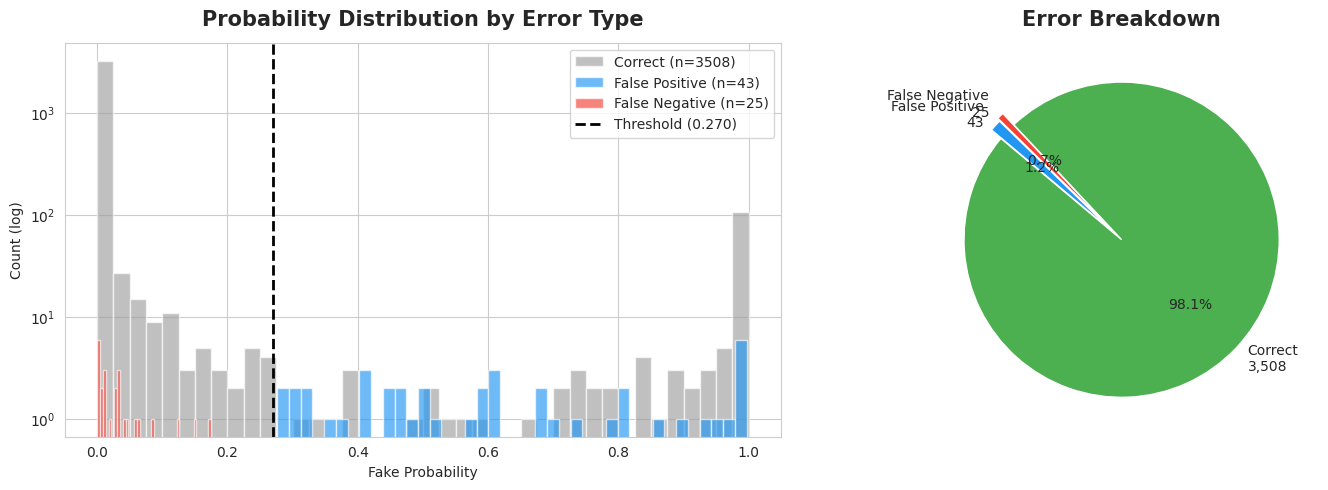

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for etype, color, z in [("Correct","#9E9E9E",1),
                         ("False Positive",COLOR_REAL,2),
                         ("False Negative",COLOR_FAKE,3)]:
    sub = err_df[err_df["error_type"]==etype]["fake_prob"]
    if len(sub) > 0:
        axes[0].hist(sub, bins=40, alpha=0.65, label=f"{etype} (n={len(sub)})",
                     color=color, edgecolor="white", zorder=z)

axes[0].axvline(FINAL_THRESHOLD, color="black", lw=2, ls="--",
                label=f"Threshold ({FINAL_THRESHOLD:.3f})")
axes[0].set_xlabel("Fake Probability"); axes[0].set_ylabel("Count (log)")
axes[0].set_yscale("log")
axes[0].set_title("Probability Distribution by Error Type", **PLOT_TITLE_KWARGS)
axes[0].legend()

axes[1].pie(
    [n_total-n_fn-n_fp, n_fn, n_fp],
    labels=[f"Correct\n{n_total-n_fn-n_fp:,}",
            f"False Negative\n{n_fn}",
            f"False Positive\n{n_fp}"],
    colors=["#4CAF50", COLOR_FAKE, COLOR_REAL],
    explode=(0, 0.1, 0.08), autopct="%1.1f%%", startangle=140,
    textprops={"fontsize":10}
)
axes[1].set_title("Error Breakdown", **PLOT_TITLE_KWARGS)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER,"error_analysis.png"),dpi=150)
plt.show()

 Inspeksi False Negative (Fake yang Lolos)

In [ ]:
print("=" * 60)
print("  FALSE NEGATIVE — FAKE YANG LOLOS DETEKSI")
print("  (Ini yang paling berbahaya — berpotensi kena korban)")
print("=" * 60)

fn_samples = err_df[err_df["error_type"]=="False Negative"] \
             .sort_values("fake_prob", ascending=False).head(5)

for rank, (_, row) in enumerate(fn_samples.iterrows(), 1):
    oidx  = int(row["orig_idx"])
    title = df["title"].iloc[oidx]    if oidx < len(df) else "N/A"
    text  = df["full_text"].iloc[oidx] if oidx < len(df) else "N/A"
    print(f"\n  [FN #{rank}]  Fake prob = {row['fake_prob']:.4f}  (threshold={FINAL_THRESHOLD:.3f})")
    print(f"  Title : {str(title)[:90]}")
    print(f"  Teks  : {str(text)[:250]}...")

  FALSE NEGATIVE — FAKE YANG LOLOS DETEKSI
  (Ini yang paling berbahaya — berpotensi kena korban)

  [FN #1]  Fake prob = 0.1742  (threshold=0.270)
  Title : Document Control Specialist
  Teks  : Document Control Specialist Maynard Consulting Company has more than 20 years experience in the biotechnology, pharmaceutical, medical device, chemical, and validation engineering fields. In addition, we have over 10 years in project management, soft...

  [FN #2]  Fake prob = 0.1517  (threshold=0.270)
  Title : Senior Engineer
  Teks  : Senior Engineer  Apply using below link#URL_1eead1e24bbaa4318ccfc699c375729468563e0ecd898e79886a53f1b51d39bf#At Puget SoundEnergy (PSE) we have a long tradition of service, and anexciting and innovative future ahead!Consider PSE for the next step in ...

  [FN #3]  Fake prob = 0.1256  (threshold=0.270)
  Title : Home Based Typist (Full/Part Time)
  Teks  : Home Based Typist (Full/Part Time)  Are you looking for a job that allows you to work flexibly at your ow

 Inspeksi False Positive (Real yang Salah Flag)

In [ ]:
print("=" * 60)
print("  FALSE POSITIVE — REAL YANG SALAH DIANGGAP FAKE")
print("=" * 60)

fp_samples = err_df[err_df["error_type"]=="False Positive"] \
             .sort_values("fake_prob", ascending=False).head(5)

for rank, (_, row) in enumerate(fp_samples.iterrows(), 1):
    oidx  = int(row["orig_idx"])
    title = df["title"].iloc[oidx]    if oidx < len(df) else "N/A"
    text  = df["full_text"].iloc[oidx] if oidx < len(df) else "N/A"
    print(f"\n  [FP #{rank}]  Fake prob = {row['fake_prob']:.4f}")
    print(f"  Title : {str(title)[:90]}")
    print(f"  Teks  : {str(text)[:250]}...")

  FALSE POSITIVE — REAL YANG SALAH DIANGGAP FAKE

  [FP #1]  Fake prob = 0.9968
  Title : Project Manager
  Teks  : Project Manager  Yes, this is a commission job in which you have to travel for but with high risk comes high reward which is why we pay our sales team so well.Here are the facts:We help homeowners out after their property has been damaged by hail sto...

  [FP #2]  Fake prob = 0.9948
  Title : TECHNICAL SUPPORT REPRESENTATIVE
  Teks  : TECHNICAL SUPPORT REPRESENTATIVE  ONE DAY HIRING TOMORROW, MARCH 19, 2014.CALLING THE ATTENTION OF ALL CALL CENTER AGENTS who has at least 2 YEARS EXPERIENCE AS TECHNICAL SUPPORT in which 6 MONTHS IS IN ISP ACCOUNT. EARN as much as 25,000 with compet...

  [FP #3]  Fake prob = 0.9922
  Title : Medium/Heavy duty gas and diesel technician
  Teks  : Medium/Heavy duty gas and diesel technician    Major's RV the premier RV service center for the south shore, cape and islands is accepting applications for a medium/heavy duty gas and diesel techni

 Pola Panjang Teks di Error Cases

In [ ]:
err_df["text_len"] = [
    len(str(df["full_text"].iloc[int(i)])) if int(i) < len(df) else 0
    for i in err_df["orig_idx"]
]

display(
    err_df.groupby("error_type")["text_len"]
          .describe()[["count","mean","50%","min","max"]]
          .rename(columns={"50%":"median"})
          .round(0)
)

print("  INTERPRETASI:")
print("  False Negative: penipu pakai bahasa formal + teks panjang")
print("  False Positive: lowongan sales/remote dengan bahasa persuasif")

,count,mean,median,min,max
error_type,,,,,
Correct,3508.0,2741.0,2584.0,83.0,11834.0
False Negative,25.0,1569.0,1373.0,193.0,3741.0
False Positive,43.0,1706.0,1687.0,264.0,3800.0


  INTERPRETASI:
  False Negative: penipu pakai bahasa formal + teks panjang
  False Positive: lowongan sales/remote dengan bahasa persuasif


 Feature Importance (Top FAKE vs REAL Indicators)

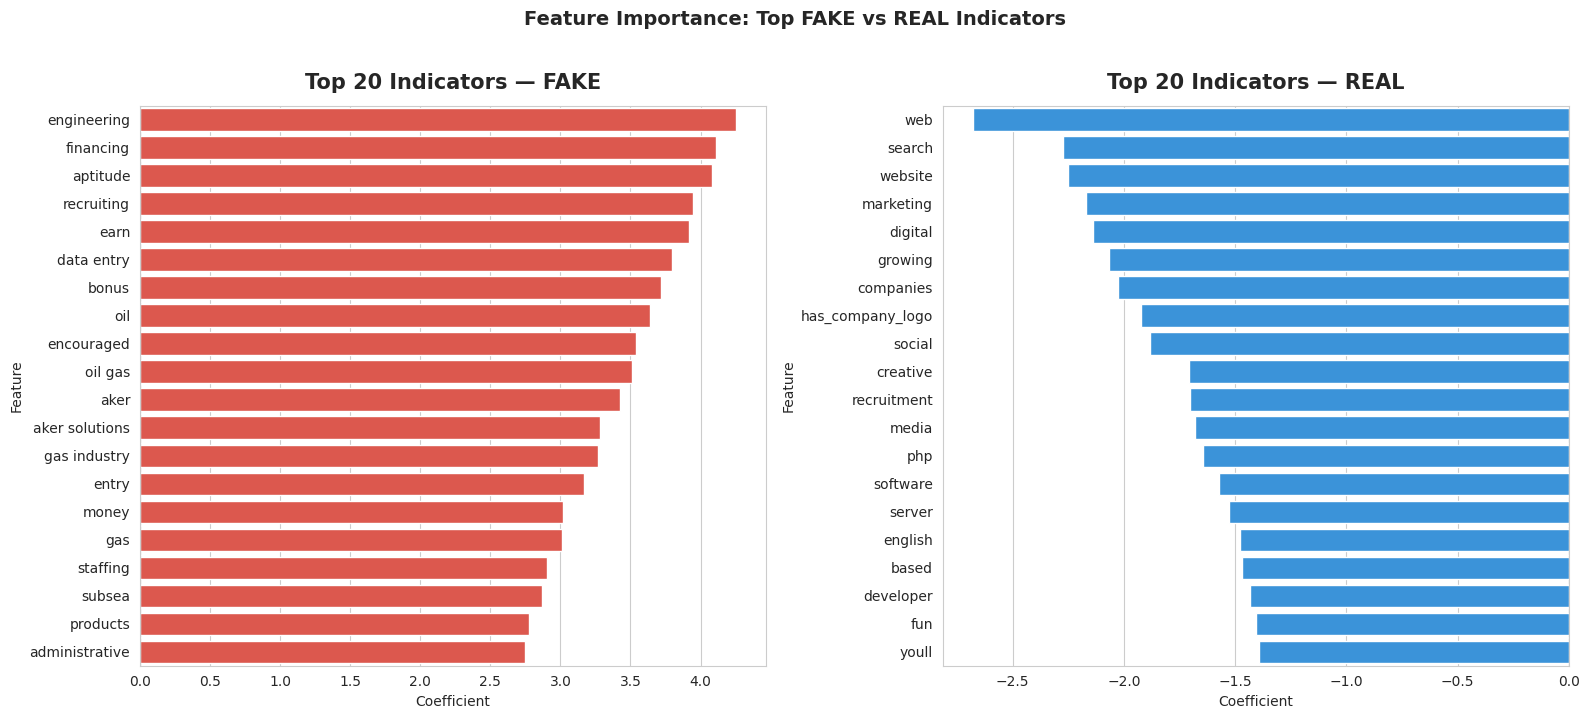

In [ ]:
try:
    feat_tfidf   = np.array(tfidf.get_feature_names_out())
    feat_eng     = np.array(ENGINEERED_FEATURES)
    all_feats    = np.concatenate([feat_tfidf, feat_eng])

    lr_model = next((r["_model"] for r in results
                     if r["Model"]=="Logistic Regression"), None)

    if lr_model is not None and hasattr(lr_model, "coef_") and len(all_feats)==len(lr_model.coef_[0]):
        coef = lr_model.coef_[0]
        TOP  = 20

        top_fake = pd.DataFrame({
            "Feature": all_feats[coef.argsort()[-TOP:][::-1]],
            "Coefficient": coef[coef.argsort()[-TOP:][::-1]]
        })
        top_real = pd.DataFrame({
            "Feature": all_feats[coef.argsort()[:TOP]],
            "Coefficient": coef[coef.argsort()[:TOP]]
        })

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        sns.barplot(data=top_fake, x="Coefficient", y="Feature",
                    color=COLOR_FAKE, ax=axes[0])
        axes[0].set_title(f"Top {TOP} Indicators — FAKE", **PLOT_TITLE_KWARGS)
        axes[0].axvline(0, color="gray", lw=0.8, ls="--")

        sns.barplot(data=top_real, x="Coefficient", y="Feature",
                    color=COLOR_REAL, ax=axes[1])
        axes[1].set_title(f"Top {TOP} Indicators — REAL", **PLOT_TITLE_KWARGS)
        axes[1].axvline(0, color="gray", lw=0.8, ls="--")

        plt.suptitle("Feature Importance: Top FAKE vs REAL Indicators",
                     fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_FOLDER,"feature_importance.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("⚠️  Dimensi tidak cocok. Pastikan LR dilatih dengan X_combined.")
except Exception as e:
    print(f"⚠️  Feature importance error: {e}")

 SHAP Per-Instance Explainability

In [ ]:
if not SHAP_AVAILABLE:
    print("⚠️  SHAP belum terinstal. Jalankan: !pip install shap -q")
else:
    try:
        lr_shap = next((r["_model"] for r in results
                        if r["Model"]=="Logistic Regression"), None)
        if lr_shap is None:
            lr_shap = LogisticRegression(C=1.0, max_iter=1000,
                                          class_weight="balanced", random_state=42)
            lr_shap.fit(X_train_sm, y_train_sm)

        feat_tfidf = np.array(tfidf.get_feature_names_out())
        feat_eng   = np.array(ENGINEERED_FEATURES)
        all_feats  = np.concatenate([feat_tfidf, feat_eng])

        N_BG = 100
        X_bg = X_train_sm[:N_BG]
        if hasattr(X_bg, "toarray"): X_bg = X_bg.toarray()

        print("  Initializing SHAP explainer...")
        explainer = None

        try:
            explainer = shap.LinearExplainer(lr_shap, X_bg)
            print("  ✅ LinearExplainer (no params)")
        except Exception:
            try:
                masker    = shap.maskers.Independent(X_bg, max_samples=N_BG)
                explainer = shap.LinearExplainer(lr_shap, masker)
                print("  ✅ LinearExplainer + masker")
            except Exception:
                explainer = shap.Explainer(lr_shap, X_bg)
                print("  ✅ shap.Explainer generic")

        N_SHAP = min(200, X_test.shape[0])
        X_shap = X_test[:N_SHAP]
        if hasattr(X_shap, "toarray"): X_shap = X_shap.toarray()

        sv = explainer.shap_values(X_shap)
        if isinstance(sv, list):   sv = sv[1]
        if hasattr(sv, "values"):  sv = sv.values
        if sv.ndim == 3:           sv = sv[:, :, 1]

        print(f"  SHAP values shape: {sv.shape}")

    except Exception as e:
        print(f"⚠️  SHAP setup error: {e}")
        sv = None

  Initializing SHAP explainer...
  ✅ LinearExplainer (no params)
  SHAP values shape: (200, 5013)


 SHAP Waterfall Plot (Per Instance)

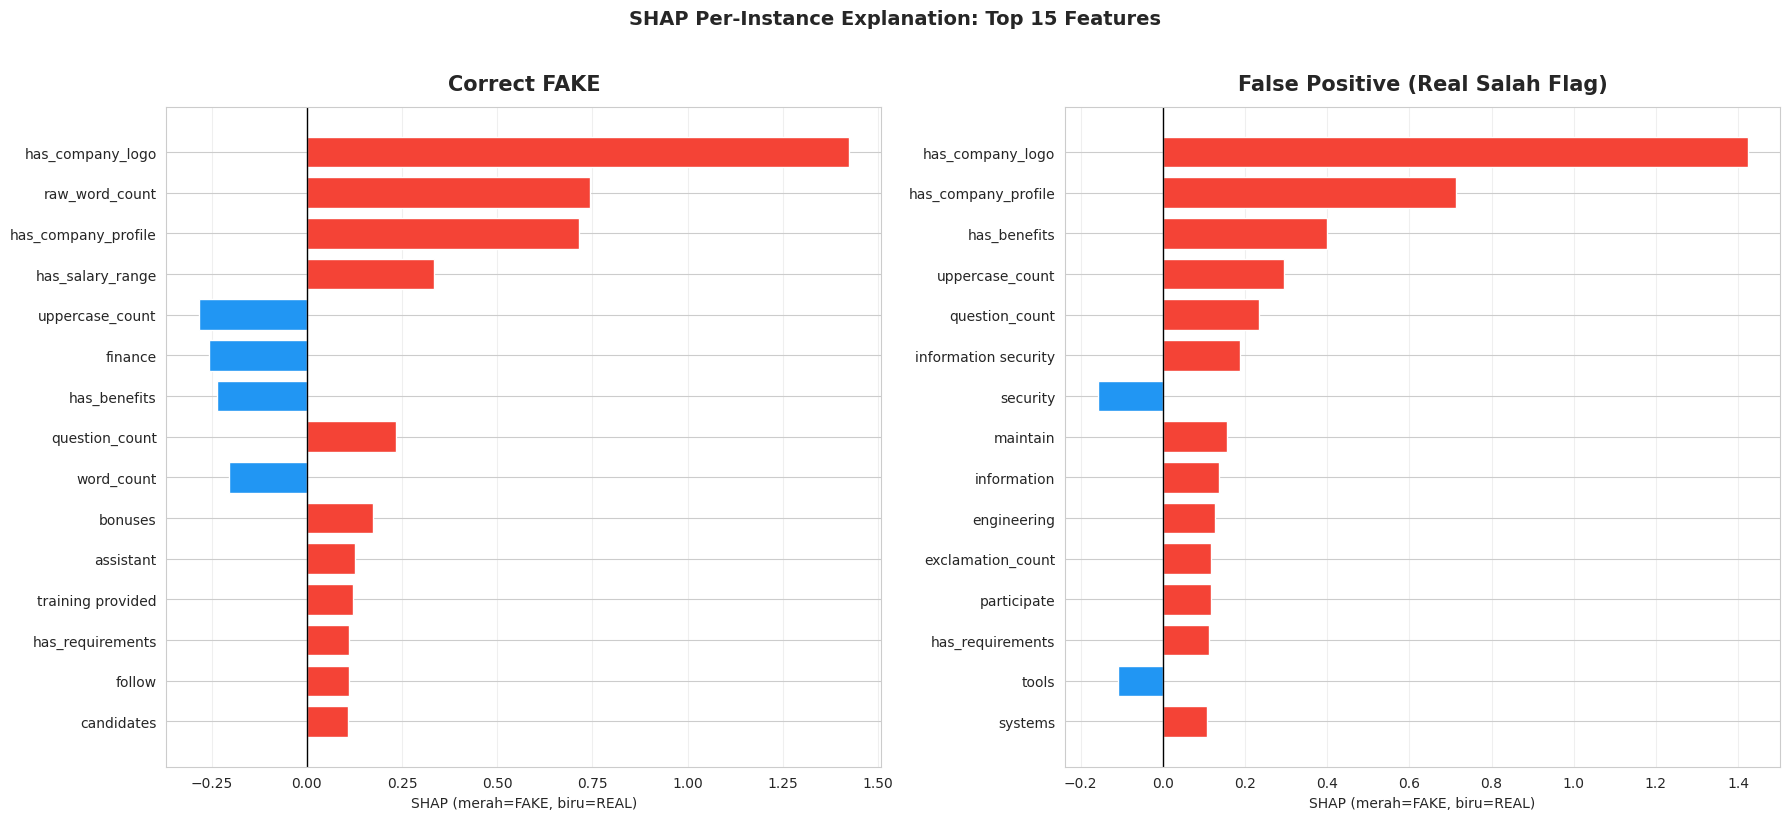

In [ ]:
if SHAP_AVAILABLE and sv is not None:
    pred_s = lr_shap.predict(X_shap)
    y_s    = np.array(y_test)[:N_SHAP]

    fn_list = [i for i in range(N_SHAP) if y_s[i]==1 and pred_s[i]==0]
    fp_list = [i for i in range(N_SHAP) if y_s[i]==0 and pred_s[i]==1]
    ok_fake = [i for i in range(N_SHAP) if y_s[i]==1 and pred_s[i]==1]
    ok_real = [i for i in range(N_SHAP) if y_s[i]==0 and pred_s[i]==0]

    pairs = []
    if fn_list: pairs.append(("False Negative (Fake Lolos)", fn_list[0], COLOR_FAKE))
    elif ok_fake: pairs.append(("Correct FAKE", ok_fake[0], COLOR_FAKE))
    if fp_list: pairs.append(("False Positive (Real Salah Flag)", fp_list[0], COLOR_REAL))
    elif ok_real: pairs.append(("Correct REAL", ok_real[0], COLOR_REAL))

    fig, axes = plt.subplots(1, len(pairs), figsize=(9*len(pairs), 8))
    if len(pairs)==1: axes = [axes]

    for ax, (label, idx, _) in zip(axes, pairs):
        sv_i     = sv[idx]
        top_idx  = np.argsort(np.abs(sv_i))[-15:]
        top_sv   = sv_i[top_idx]
        top_feat = all_feats[top_idx]

        bar_cols = [COLOR_FAKE if v>0 else COLOR_REAL for v in top_sv]
        ax.barh(range(15), top_sv, color=bar_cols, edgecolor="white", height=0.75)
        ax.set_yticks(range(15))
        ax.set_yticklabels(top_feat, fontsize=10)
        ax.axvline(0, color="black", lw=1)
        ax.set_xlabel("SHAP (merah=FAKE, biru=REAL)", fontsize=10)
        ax.set_title(f"{label}", **PLOT_TITLE_KWARGS)
        ax.grid(True, alpha=0.3, axis="x")

    plt.suptitle("SHAP Per-Instance Explanation: Top 15 Features",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER,"shap_waterfall.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠️  SHAP tidak tersedia atau sv=None.")

 SHAP Global Summary Plot

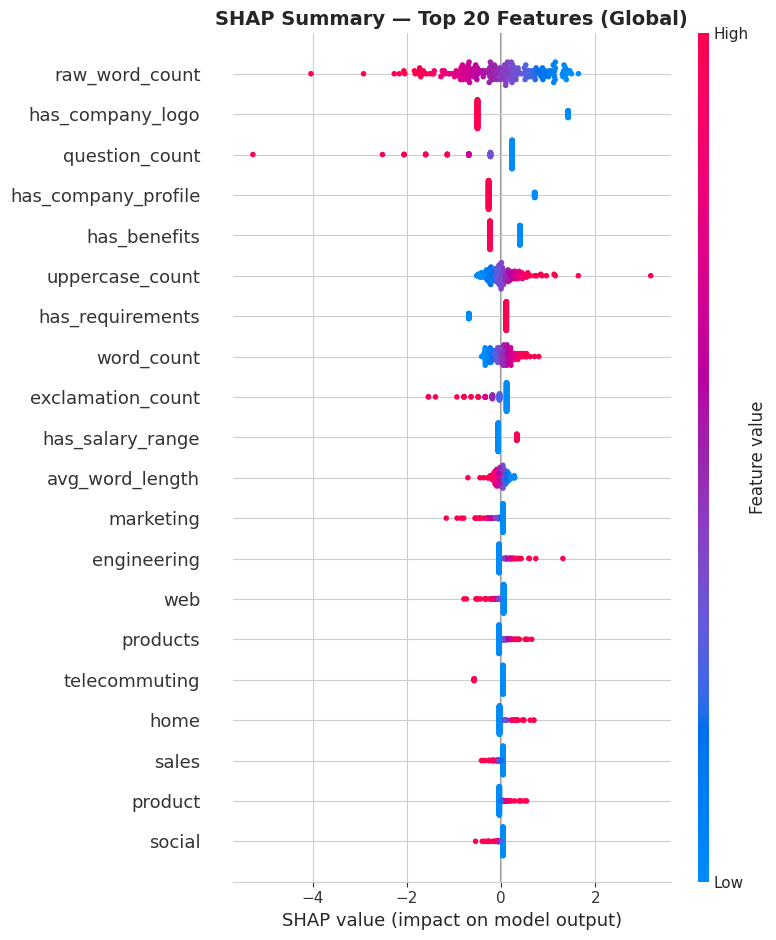

  Plot tersimpan: shap_summary.png


In [ ]:
if SHAP_AVAILABLE and sv is not None:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_shap, feature_names=all_feats,
                      max_display=20, show=False, plot_type="dot")
    plt.title("SHAP Summary — Top 20 Features (Global)",
              fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER,"shap_summary.png"),dpi=150)
    plt.show()
    print("  Plot tersimpan: shap_summary.png")
else:
    print("⚠️  SHAP tidak tersedia.")

 Ensemble Voting Classifier

In [ ]:
print("=" * 60)
print("  ENSEMBLE VOTING CLASSIFIER")
print("=" * 60)
print("  Menggabungkan 3 model terbaik dengan soft voting.")

top3_names = metrics_df["F1-Score"].nlargest(3).index.tolist()
voting_est = [
    (r["Model"].replace(" ","_"), r["_model"])
    for r in results
    if r["Model"] in top3_names and r["Model"] != "Multinomial NB"
]

print(f"  Estimators: {[e[0] for e in voting_est]}")

voting_clf = VotingClassifier(estimators=voting_est, voting="soft")
voting_clf.fit(X_train_sm, y_train_sm)

ens_result = evaluate_model("Ensemble Voting", voting_clf,
                             X_train_sm, y_train_sm, X_test, y_test)

print(f"\n  Ensemble Results:")
print(f"  F1-Score : {ens_result['F1-Score']:.4f}")
print(f"  Recall   : {ens_result['Recall']:.4f}")
print(f"  Precision: {ens_result['Precision']:.4f}")
print(f"  ROC-AUC  : {ens_result['ROC-AUC']:.4f}")
print(f"\n  Model individual terbaik ({best_model_name}): F1={best_result['F1-Score']:.4f}")

  ENSEMBLE VOTING CLASSIFIER
  Menggabungkan 3 model terbaik dengan soft voting.
  Estimators: ['Linear_SVM', 'Random_Forest', 'XGBoost']

  Ensemble Results:
  F1-Score : 0.8421
  Recall   : 0.7399
  Precision: 0.9771
  ROC-AUC  : 0.9932

  Model individual terbaik (Linear SVM): F1=0.8291


 Pilih Model Final

In [ ]:
# Bandingkan: tuned SVM (dari C sweep + threshold opt) vs ensemble
tuned_final = eval_at_thr(y_test, best_sweep_prob, FINAL_THRESHOLD)

if ens_result["F1-Score"] > tuned_final["F1"]:
    final_model_obj  = voting_clf
    final_name       = "Ensemble Voting Classifier"
    final_f1         = ens_result["F1-Score"]
    final_recall     = ens_result["Recall"]
    final_auc        = ens_result["ROC-AUC"]
else:
    final_model_obj  = best_sweep_model
    final_name       = f"Linear SVM (C={best_C}, thr={FINAL_THRESHOLD:.3f})"
    final_f1         = tuned_final["F1"]
    final_recall     = tuned_final["Recall"]
    final_auc        = best_sweep_row["AUC"]

print("=" * 60)
print(f"  🏆 FINAL MODEL : {final_name}")
print("=" * 60)
print(f"  F1-Score  : {final_f1:.4f}")
print(f"  Recall    : {final_recall:.4f}")
print(f"  ROC-AUC   : {final_auc:.4f}")
print(f"  Threshold : {FINAL_THRESHOLD:.4f}")

  🏆 FINAL MODEL : Ensemble Voting Classifier
  F1-Score  : 0.8421
  Recall    : 0.7399
  ROC-AUC   : 0.9932
  Threshold : 0.2698


 Save Model & Vectorizer

In [ ]:
model_path  = os.path.join(OUTPUT_FOLDER, "trained_model.pkl")
tfidf_path  = os.path.join(OUTPUT_FOLDER, "tfidf_vectorizer.pkl")
feat_path   = os.path.join(OUTPUT_FOLDER, "engineered_features.pkl")

joblib.dump(final_model_obj, model_path)
joblib.dump(tfidf,           tfidf_path)
joblib.dump(ENGINEERED_FEATURES, feat_path)

print("=" * 60)
print("  MODELS SAVED")
print("=" * 60)
print(f"  Model      : {model_path}")
print(f"  Vectorizer : {tfidf_path}")
print(f"  Features   : {feat_path}")
print("=" * 60)

  MODELS SAVED
  Model      : /content/drive/MyDrive/machine learning/trained_model.pkl
  Vectorizer : /content/drive/MyDrive/machine learning/tfidf_vectorizer.pkl
  Features   : /content/drive/MyDrive/machine learning/engineered_features.pkl


 Prediction Function (Inference Pipeline)

In [ ]:
import re, string as _str
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as ENG_SW

_CUSTOM_SW = {
    "experience","work","working","team","job","jobs","skills","skill",
    "candidate","company","looking","ability","new","year","years",
    "business","employee","employees","position","role","opportunity",
    "great","good","time","need","provide","including","required","will","must"
}
_ALL_SW = ENG_SW.union(_CUSTOM_SW)

def _clean_inf(text):
    text = str(text).lower()
    text = text.encode("ascii","ignore").decode("ascii")
    text = re.sub(r"http\S+|www\.\S+","",text)
    text = re.sub(r"<[^>]+>","",text)
    text = re.sub(r"\d+","",text)
    text = text.translate(str.maketrans("","",_str.punctuation))
    text = re.sub(r"\s+"," ",text).strip()
    return " ".join(w for w in text.split() if w not in _ALL_SW)


def predict_job_posting(raw_text, model=None, vectorizer=None,
                         threshold=None, features=None):
    """Prediksi apakah teks lowongan Real atau Fake."""
    if model      is None: model      = final_model_obj
    if vectorizer is None: vectorizer = tfidf
    if threshold  is None: threshold  = FINAL_THRESHOLD
    if features   is None: features   = ENGINEERED_FEATURES

    cleaned = _clean_inf(raw_text)

    # TF-IDF
    X_t = vectorizer.transform([cleaned])

    # Engineered features
    eng_vals = []
    for feat in features:
        if feat == "uppercase_count":   eng_vals.append(sum(c.isupper() for c in raw_text))
        elif feat == "exclamation_count": eng_vals.append(raw_text.count("!"))
        elif feat == "question_count":    eng_vals.append(raw_text.count("?"))
        elif feat == "word_count":        eng_vals.append(len(cleaned.split()))
        elif feat == "avg_word_length":
            ws = cleaned.split()
            eng_vals.append(np.mean([len(w) for w in ws]) if ws else 0)
        elif feat == "raw_word_count":    eng_vals.append(len(raw_text.split()))
        # Binary features — default 0 saat inference
        else:                             eng_vals.append(0)

    X_e     = csr_matrix([eng_vals])
    X_input = hstack([X_t, X_e])

    if hasattr(model,"predict_proba"):
        fake_prob = model.predict_proba(X_input)[0][1]
    elif hasattr(model,"decision_function"):
        sc = model.decision_function(X_input)[0]
        fake_prob = 1 / (1 + np.exp(-sc))
    else:
        fake_prob = float(model.predict(X_input)[0])

    label     = "FAKE" if fake_prob >= threshold else "REAL"
    risk_tier = ("Low Risk" if fake_prob<0.3 else
                 "Medium Risk" if fake_prob<0.6 else "High Risk")

    return {
        "label"     : label,
        "fake_prob" : round(float(fake_prob), 4),
        "real_prob" : round(1-float(fake_prob), 4),
        "risk_tier" : risk_tier,
        "confidence": f"{max(fake_prob, 1-fake_prob)*100:.1f}%",
    }

print("✅ predict_job_posting() siap digunakan")

✅ predict_job_posting() siap digunakan


 Demo Prediksi

In [ ]:
demos = [
    {
        "label": "Contoh 1 — Kemungkinan FAKE",
        "text" : ("WORK FROM HOME! Earn $500-$5000 per week! No experience needed! "
                  "Join our team and start making money immediately! 100% guaranteed! "
                  "Apply NOW! Limited spots available!!! Data entry specialists needed.")
    },
    {
        "label": "Contoh 2 — Kemungkinan REAL",
        "text" : ("Software Engineer — Python & Machine Learning. "
                  "We are seeking a mid-level Software Engineer with 3+ years of "
                  "experience in Python, TensorFlow, and cloud infrastructure (AWS/GCP). "
                  "Responsibilities include designing ML pipelines. BSc in CS required.")
    },
    {
        "label": "Contoh 3 — Borderline",
        "text" : ("Sales Representative needed. Work from home possible. "
                  "Competitive commission. Training provided. Good communication required.")
    }
]

for d in demos:
    r    = predict_job_posting(d["text"])
    icon = "🔴" if r["label"]=="FAKE" else "🔵"
    print(f"\n  {d['label']}")
    print(f"  {'='*55}")
    print(f"  {icon} Prediksi   : {r['label']}")
    print(f"     Prob Fake : {r['fake_prob']:.4f}")
    print(f"     Risk Tier : {r['risk_tier']}")
    print(f"     Confidence: {r['confidence']}")


  Contoh 1 — Kemungkinan FAKE
  🔴 Prediksi   : FAKE
     Prob Fake : 0.8938
     Risk Tier : High Risk
     Confidence: 89.4%

  Contoh 2 — Kemungkinan REAL
  🔵 Prediksi   : REAL
     Prob Fake : 0.1312
     Risk Tier : Low Risk
     Confidence: 86.9%

  Contoh 3 — Borderline
  🔴 Prediksi   : FAKE
     Prob Fake : 0.4233
     Risk Tier : Medium Risk
     Confidence: 57.7%


 Deliverables Checklist

In [ ]:
deliverables = {
    "trained_model.pkl"          : os.path.join(OUTPUT_FOLDER, "trained_model.pkl"),
    "tfidf_vectorizer.pkl"       : os.path.join(OUTPUT_FOLDER, "tfidf_vectorizer.pkl"),
    "engineered_features.pkl"    : os.path.join(OUTPUT_FOLDER, "engineered_features.pkl"),
    "fake_job_app.py"            : os.path.join(OUTPUT_FOLDER, "fake_job_app.py"),
    "cleaned_fake_job_dataset.csv": os.path.join(OUTPUT_FOLDER, "cleaned_fake_job_dataset.csv"),
    "confusion_matrices.png"     : os.path.join(OUTPUT_FOLDER, "confusion_matrices.png"),
    "roc_curves.png"             : os.path.join(OUTPUT_FOLDER, "roc_curves.png"),
    "threshold_optimization.png" : os.path.join(OUTPUT_FOLDER, "threshold_optimization.png"),
    "error_analysis.png"         : os.path.join(OUTPUT_FOLDER, "error_analysis.png"),
    "svm_c_sweep.png"            : os.path.join(OUTPUT_FOLDER, "svm_c_sweep.png"),
    "feature_importance.png"     : os.path.join(OUTPUT_FOLDER, "feature_importance.png"),
    "shap_waterfall.png"         : os.path.join(OUTPUT_FOLDER, "shap_waterfall.png"),
}

print("=" * 60)
print("  DELIVERABLES CHECKLIST")
print("=" * 60)
for fname, fpath in deliverables.items():
    status = "" if os.path.exists(fpath) else "⚠️ "
    print(f"  {status} {fname}")

  DELIVERABLES CHECKLIST
  ✅ trained_model.pkl
  ✅ tfidf_vectorizer.pkl
  ✅ engineered_features.pkl
  ⚠️  fake_job_app.py
  ✅ cleaned_fake_job_dataset.csv
  ✅ confusion_matrices.png
  ✅ roc_curves.png
  ✅ threshold_optimization.png
  ✅ error_analysis.png
  ✅ svm_c_sweep.png
  ✅ feature_importance.png
  ✅ shap_waterfall.png



Evaluation Summary

In [ ]:
print("=" * 60)
print("  FINAL EVALUATION SUMMARY")
print("=" * 60)
print(f"  Model Final  : {final_name}")
print(f"  Threshold    : {FINAL_THRESHOLD:.4f}")
print(f"  F1-Score     : {final_f1:.4f}")
print(f"  Recall       : {final_recall:.4f}")
print(f"  ROC-AUC      : {final_auc:.4f}")
print(f"  AP (PR-AUC)  : {avg_prec:.4f}")

  FINAL EVALUATION SUMMARY
  Model Final  : Ensemble Voting Classifier
  Threshold    : 0.2698
  F1-Score     : 0.8421
  Recall       : 0.7399
  ROC-AUC      : 0.9932
  AP (PR-AUC)  : 0.9030


In [ ]:
import shutil

OLD_FOLDER = "/content/drive/MyDrive/machine learning"
NEW_FOLDER = "/content/drive/MyDrive/machine learning/fake_job_results"
os.makedirs(NEW_FOLDER, exist_ok=True)

# File-file yang mau dipindah
files_to_move = [
    "trained_model.pkl",
    "tfidf_vectorizer.pkl",
    "engineered_features.pkl",
    "cleaned_fake_job_dataset.csv",
    "fake_job_app.py",
    "confusion_matrices.png",
    "roc_curves.png",
    "threshold_optimization.png",
    "error_analysis.png",
    "svm_c_sweep.png",
    "feature_importance.png",
    "shap_waterfall.png",
    "shap_summary.png",
    "overfitting_analysis.png",
    "smote_distribution.png",
    "target_distribution.png",
    "missing_values.png",
    "binary_features_eda.png",
    "text_length.png",
    "top_words.png",
    "wordcloud_real.png",
    "wordcloud_fake.png",
    "tfidf_top_terms.png",
    "feature_boxplot.png",
]

moved, skipped = 0, 0
for fname in files_to_move:
    src = os.path.join(OLD_FOLDER, fname)
    dst = os.path.join(NEW_FOLDER, fname)
    if os.path.exists(src):
        shutil.move(src, dst)
        moved += 1
    else:
        skipped += 1

print(f" Dipindah : {moved} file")
print(f"  Skip    : {skipped} file (belum ada)")
print(f"Sekarang ada di: {NEW_FOLDER}")

✅ Dipindah : 23 file
⚠️  Skip    : 1 file (belum ada)
📁 Sekarang ada di: /content/drive/MyDrive/machine learning/fake_job_results
